# **Trabajo Práctico N°1**
### Aprendizaje Automático I
#### Abril 2026

####**Estudiantes**:

Diez Laureano

Duvia Uriel

Quispe Rocio

## **Enunciado: Modelo predictivo de tarifas de Uber**


El objetivo de este trabajo es desarrollar un modelo de regresión capaz de predecir la tarifa de un viaje de Uber a partir de variables como la distancia, la cantidad de pasajeros y las coordenadas geográficas de origen y destino.

Se busca aplicar técnicas de análisis exploratorio de datos, preprocesamiento y modelado utilizando herramientas de aprendizaje automático en Python, con el fin de evaluar el desempeño del modelo y comprender la relación entre las variables involucradas.

####**Objetivos**
Familiarizarse con la biblioteca scikit-learn y las herramientas que brinda para el pre-procesamiento de datos, la implementación de modelos de regresión lineal con diversos hiperparámetros y la evaluación de métricas de regresión.



####**Dataset**

El dataset se llama uber_fares.csv y contiene información de tarifas de viajes realizados, además de distintas variables características, como se detallan a continuación.



####**Características de entrada:**

**key** - un identificador único para cada viaje.

**pickup_datetime** - fecha y hora en que se activó el taxímetro.

**passenger_count** - el número de pasajeros en el vehículo (valor ingresado por el conductor).

**pickup_longitude** - la longitud donde se activó el taxímetro.

**pickup_latitude** - la latitud donde se activó el taxímetro.

**dropoff_longitude** - la longitud donde se desactivó el taxímetro.

**dropoff_latitude** - la latitud donde se desactivó el taxímetro.


Variable de salida (target): **fare_amount** - el costo de cada viaje en USD

Para todos los ítems, incorporar una cantidad de texto adecuado en forma de comentarios, ya sea para la comprensión del código (usualmente una línea de comentario por cada celda) como para explicar las decisiones tomadas a lo largo del trabajo (por ejemplo, la justificación de la imputación de valores faltantes, la elección de las métricas adecuadas, entre otros). Mantener la coherencia con los comentarios.


###**Consignas**
**3-** Realizar un análisis descriptivo, que ayude a la comprensión del problema, de cada una de las variables involucradas en el problema detallando características, comportamiento y rango de variación.

Debe incluir, en el orden que lo crean adecuado:


*   Análisis y decisión sobre datos faltantes.
*   Análisis y decisión sobre datos atípicos.
*   Visualización de datos (histogramas de distribuciones de todas las variables, scatterplots entre variables, diagramas de caja)
Codificación de variables categóricas (si se van a utilizar para predicción).
*   Matriz de correlación de variables, sobre las que correspondan.
*   Estandarización o escalado de datos.
*   Validación cruzada train - test. Realizar una división del conjunto de datos en conjuntos de entrenamiento y prueba (y si se quiere, se puede incluir validación, que luego puede ser útil) en el MOMENTO donde ustedes lo crean adecuado.

**4-** Implementar la solución del problema de regresión con regresión lineal múltiple.
*   Probar con el método LinearRegression.
*   Probar con los tres métodos de gradiente descendiente. ¿Qué observan? Incorporar gráficas de Error vs Iteraciones (loss vs epochs). Comentar qué observan en estos gráficos.
*   Probar con los métodos de regularización (Lasso, Ridge, Elastic Net). Usar un rango amplio de coeficientes de regularización.
*   Obtener las métricas adecuadas (entre R2 Score, MSE, RMSE, MAE, MAPE, elegir) tanto para entrenamiento como para prueba. ¿Por qué para ambos conjuntos?
*   Incorporar gráficos de residuos en todos los casos y analizarlos.
*   ¿Creen que han conseguido un buen fitting? ¿Qué pueden concluir de la regularización? ¿Y de gradiente descendiente?

**5-** Optimizar la selección de hiperparámetros.
*   Variar los hiperparámetros de gradiente descendiente. ¿Qué observa?
*   Variar los hiperparámetros de Lasso y Ridge. ¿Qué observa?

**6-** Comparación de modelos.
*   Incluyan en su análisis una comparación de modelos: de todos los modelos de regresión, ¿cuál es el mejor? Escoger una métrica adecuada para poder compararlos.

##3) **Carga, inspección y análisis (EDA) sobre el Dataset**

### 3.1) **Configuración del entorno**

#### Se importan las librerías necesarias

In [1]:
import pandas as pd
import numpy as np
import math

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder

###  3.2) **Carga e Inspección Estructural del Dataset**

#### Sobre el dataset Uber

In [2]:
file_path = 'uber_fares.csv'
df = pd.read_csv(file_path)

El dataset contiene informacion de tarifas de viajes realizados con las siguientes variables:

Características de entrada:


| Variable | Tipo | Descripcion |
|----------|------|-------------|
| `Key` | Entero | Identificador único para cada viaje. |
| `date` | Objeto | Fecha y hora de cada viaje. |
| `pickup_datetime` | Objeto | Fecha y hora en que se activó el taxímetro. |
| `passenger_count` | Entero | Número de pasajeros en el vehículo (valor ingresado por el conductor). |
| `pickup_longitude` | Continua |  Longitud donde se activó el taxímetro. |
| `pickup_latitude` | Continua | Latitud donde se activó el taxímetro. |
| `dropoff_longitude` | Continua | Longitud donde se desactivó el taxímetro. |
| `dropoff_latitude` | Continua | Latitud donde se desactivó el taxímetro. |
| `fare_amount` | Continua |  Costo de cada viaje en USD (target)|



In [3]:
print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria utilizada: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print()

Dimensiones del dataset: 200000 filas x 9 columnas
Memoria utilizada: 39.20 MB



#### **Visualización general del dataset**


In [4]:
df.head(10)

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:50:00,8.47,2015-05-07 19:50:00 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:00:04,7.60,2009-07-17 20:00:04 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:49:07,12.65,2009-08-24 21:49:07 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:17:45,5.01,2009-06-26 08:17:45 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:46:18,15.64,2014-08-28 17:46:18 UTC,-73.925023,40.744085,-73.973082,40.761247,5
5,44470845,2011-02-12 02:28:47,4.05,2011-02-12 02:28:47 UTC,-73.969019,40.755910,-73.969019,40.755910,1
6,48725865,2014-10-12 07:01:25,26.73,2014-10-12 07:01:25 UTC,-73.961447,40.693965,-73.871195,40.774297,5
7,44195482,2012-12-11 13:53:11,2.70,2012-12-11 13:53:11 UTC,0.000000,0.000000,0.000000,0.000000,1
8,15822268,2012-02-17 09:34:14,9.50,2012-02-17 09:34:14 UTC,-73.975187,40.745767,-74.002720,40.743537,1
9,50611056,2012-03-29 19:03:22,12.53,2012-03-29 19:03:22 UTC,-74.001065,40.741787,-73.963040,40.775012,1


Se observa que la variable key no es secuencial y las variables date y pickup_datetime tienen los mismos datos aunque en otro formato.

#### **Visualización de los datos**

In [5]:
# Inspeccion de tipos de datos y estructura
print('Tipos de datos y valores no nulos:')
print('=' * 46)
df.info()

Tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


Se observan muy pocos datos nulos


#### **Limpieza inicial de datos**

En esta etapa se realiza una limpieza inicial del dataset con el objetivo de eliminar variables que no aportan información relevante para el problema.

In [6]:
df = df.drop(columns=["key"])

In [7]:
# Corroboramos si las 2 variables date y pickup_datetime tienen los mismos datos.
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], utc=True)
df['date'] = pd.to_datetime(df['date'], utc=True)

# Verificamos si son iguales
(df['pickup_datetime'] == df['date']).all()

np.True_

In [8]:
# Eliminamos date por ser la columna igual a pickup_datetime
df = df.drop(columns=['date'])

##### Separación de variables

In [9]:
# Separacion de variables por tipo
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['category', 'object']).columns.tolist()

print(f'Variables numericas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variables categoricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numericas (6): ['fare_amount', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']
Variables categoricas (0): []


### 3.3) **Análisis descriptivo**

In [10]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,11.362915,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,9.943248,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,5.970000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,8.430000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,12.660000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,503.130000,57.418457,1644.421482,1153.572603,872.697628,208.000000


Se observa que en passenger_count el valor máximo es de 208, y en fare_amount el máximo de costo es de $508.13. Ambos son extremadamente de muy alto valor.

#### **Medidas de Tendencia Central y Descripción**

In [11]:
desc = df[cols_numericas].describe().T
desc['mediana'] = df[cols_numericas].median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df[cols_numericas].skew()
desc['curtosis'] = df[cols_numericas].kurtosis()

print('Estadisticos descriptivos completos:')
print('=' * 100)
desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]

Estadisticos descriptivos completos:


,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
fare_amount,11.362915,8.430000,9.943248,87.506143,1.000000,5.970000,8.430000,12.660000,503.130000,4.482243,62.246028
pickup_longitude,-72.527638,-73.981823,11.437787,-15.770247,-1340.648410,-73.992065,-73.981823,-73.967154,57.418457,-7.495890,1144.027459
pickup_latitude,39.935885,40.752592,7.720539,19.332336,-74.015515,40.734796,40.752592,40.767158,1644.421482,62.976856,12869.240503
dropoff_longitude,-72.525292,-73.980093,13.117408,-18.086667,-3356.666300,-73.991407,-73.980093,-73.963658,1153.572603,-71.505102,20078.722920
dropoff_latitude,39.923890,40.753042,6.794829,17.019456,-881.985513,40.733823,40.753042,40.768001,872.697628,-8.031012,2981.741917
passenger_count,1.684535,1.000000,1.385997,82.277694,0.000000,1.000000,1.000000,2.000000,208.000000,18.145521,2456.621809


In [12]:
print('Interpretacion del Sesgo y Curtosis:')
print('=' * 60)

for col in cols_numericas:
    sesgo = df[col].skew()
    curtosis = df[col].kurtosis()

    # Clasificacion del sesgo
    if abs(sesgo) < 0.5:
        tipo_sesgo = 'aproximadamente simetrica'
    elif sesgo > 0:
        tipo_sesgo = f'sesgo positivo ({"moderado" if sesgo < 1 else "alto"})'
    else:
        tipo_sesgo = f'sesgo negativo ({"moderado" if abs(sesgo) < 1 else "alto"})'

    # Clasificacion de la curtosis
    if abs(curtosis) < 0.5:
        tipo_curtosis = 'mesocurtica'
    elif curtosis > 0:
        tipo_curtosis = 'leptocurtica (colas pesadas)'
    else:
        tipo_curtosis = 'platicurtica (colas livianas)'

    print(f'  {col:>8s}: sesgo={sesgo:+.3f} [{tipo_sesgo}], '
          f'curtosis={curtosis:+.3f} [{tipo_curtosis}]')

Interpretacion del Sesgo y Curtosis:
  fare_amount: sesgo=+4.482 [sesgo positivo (alto)], curtosis=+62.246 [leptocurtica (colas pesadas)]
  pickup_longitude: sesgo=-7.496 [sesgo negativo (alto)], curtosis=+1144.027 [leptocurtica (colas pesadas)]
  pickup_latitude: sesgo=+62.977 [sesgo positivo (alto)], curtosis=+12869.241 [leptocurtica (colas pesadas)]
  dropoff_longitude: sesgo=-71.505 [sesgo negativo (alto)], curtosis=+20078.723 [leptocurtica (colas pesadas)]
  dropoff_latitude: sesgo=-8.031 [sesgo negativo (alto)], curtosis=+2981.742 [leptocurtica (colas pesadas)]
  passenger_count: sesgo=+18.146 [sesgo positivo (alto)], curtosis=+2456.622 [leptocurtica (colas pesadas)]


#### **Análisis estadístico**



El análisis descriptivo evidencia la **presencia de valores atípicos** en múltiples variables del dataset.

La variable **fare_amount presenta una fuerte asimetría positiva y alta curtosis**, lo que indica la existencia de tarifas extremadamente elevadas.

Asimismo, las variables geográficas muestran valores **fuera de los rangos posibles**, lo que evidencia errores en los datos.

Por otro lado, la variable passenger_count contiene **valores inválidos**, como cero pasajeros o cantidades excesivas.

En conjunto, **estos resultados justifican la necesidad de aplicar técnicas de limpieza de datos para mejorar la calidad del dataset antes del modelado**.

#### Gráficos de Distribución

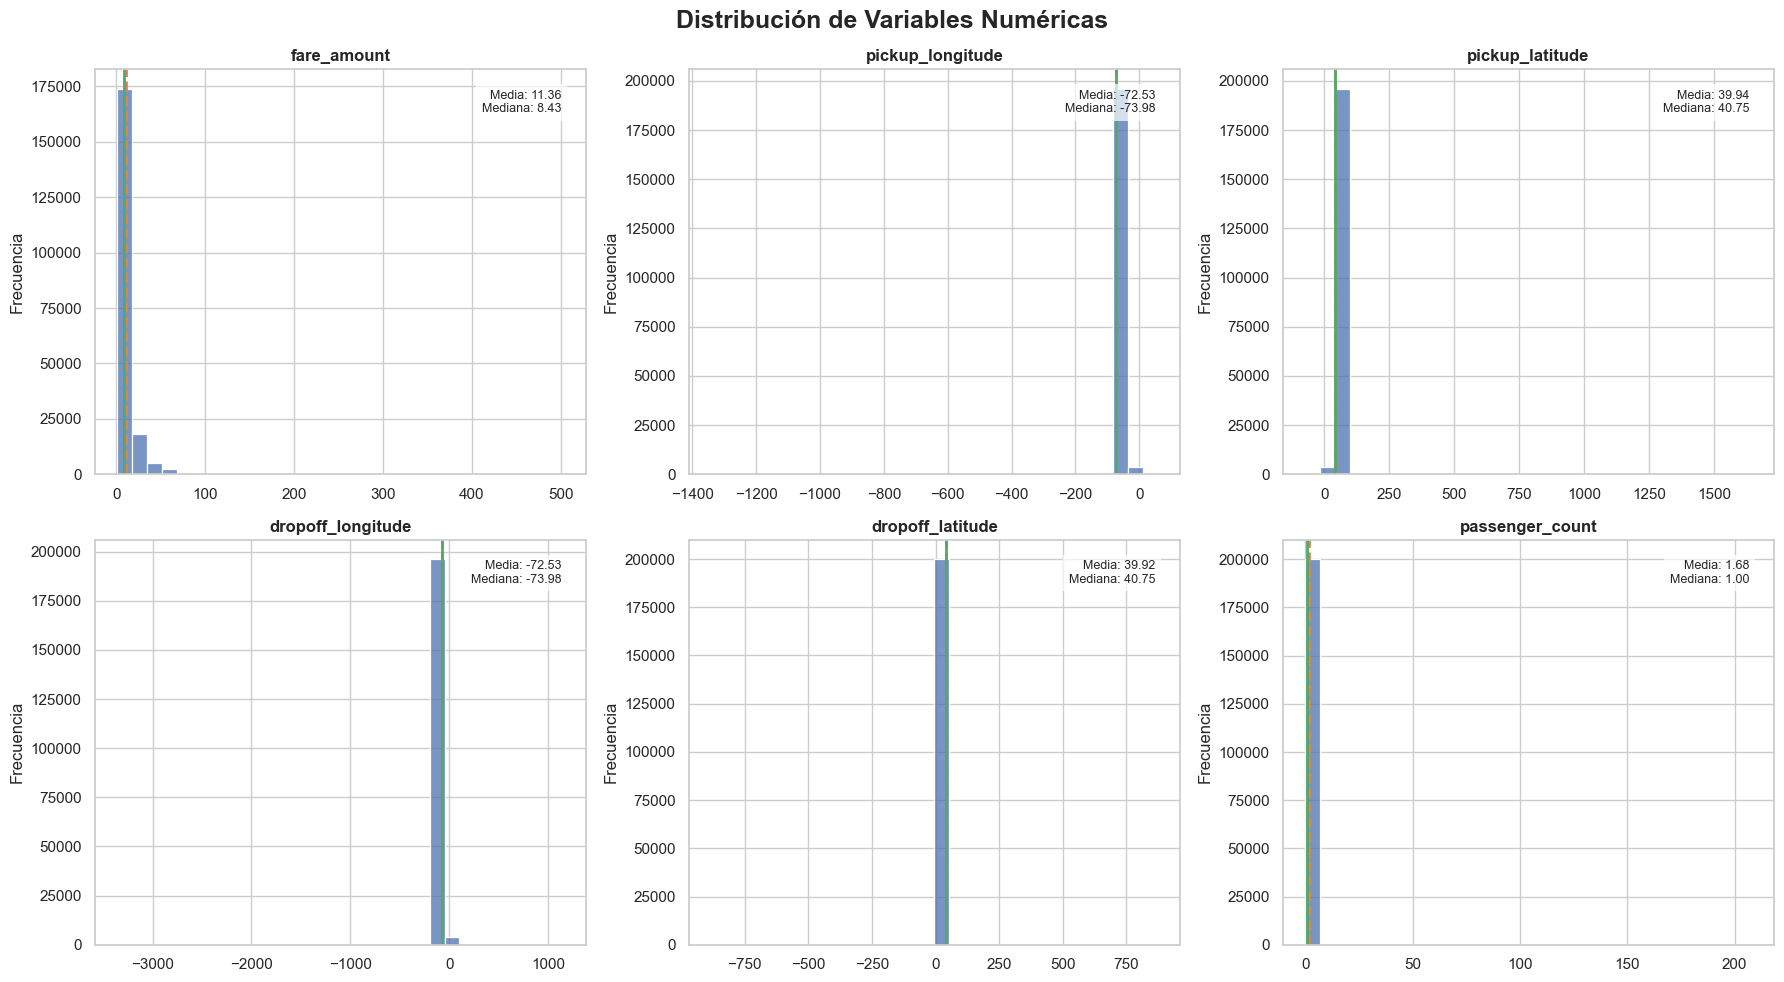

In [13]:

# estilo más profesional
sns.set_theme(style="whitegrid")

# columnas numéricas
cols_numericas = df.select_dtypes(include=np.number).columns

n = len(cols_numericas)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]

    data = df[col].dropna()

    # histograma
    sns.histplot(data, bins=30, kde=False, ax=ax,
                 color='#4C72B0', edgecolor='white')

    # media y mediana
    media = data.mean()
    mediana = data.median()

    ax.axvline(media, color='#DD8452', linestyle='--', linewidth=2)
    ax.axvline(mediana, color='#55A868', linestyle='-', linewidth=2)

    # títulos
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')

    # texto dentro del gráfico
    ax.text(0.95, 0.95,
            f'Media: {media:.2f}\nMediana: {mediana:.2f}',
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# ocultar vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas',
             fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

La variable fare_amount presenta una distribución fuertemente asimétrica hacia la derecha. La mayor parte de los viajes se concentra en valores bajos de tarifa, mientras que existe una cola larga hacia valores elevados. La media resulta superior a la mediana, lo que confirma la presencia de asimetría positiva y sugiere la existencia de valores atípicos (outliers), posiblemente asociados a errores o a viajes inusualmente largos.

Las variables geográficas (pickup_longitude, pickup_latitude, dropoff_longitude y dropoff_latitude), se observa una alta concentración de valores en rangos específicos, coherentes con la ubicación geográfica esperada (aproximadamente longitud -74 y latitud 40, correspondientes a la ciudad de Nueva York). Sin embargo, también se detectan valores extremos alejados de estos rangos, lo cual indica la presencia de datos erróneos o inconsistentes que deberían ser tratados en etapas posteriores de limpieza.

La variable passenger_count muestra una distribución discreta, con una fuerte concentración en valores bajos, particularmente en 1 pasajero. Esto resulta consistente con el comportamiento típico del servicio. No obstante, la presencia de valores inusuales (como 0 o valores excesivamente altos) podría indicar errores de carga o registros atípicos.

#### Boxplot

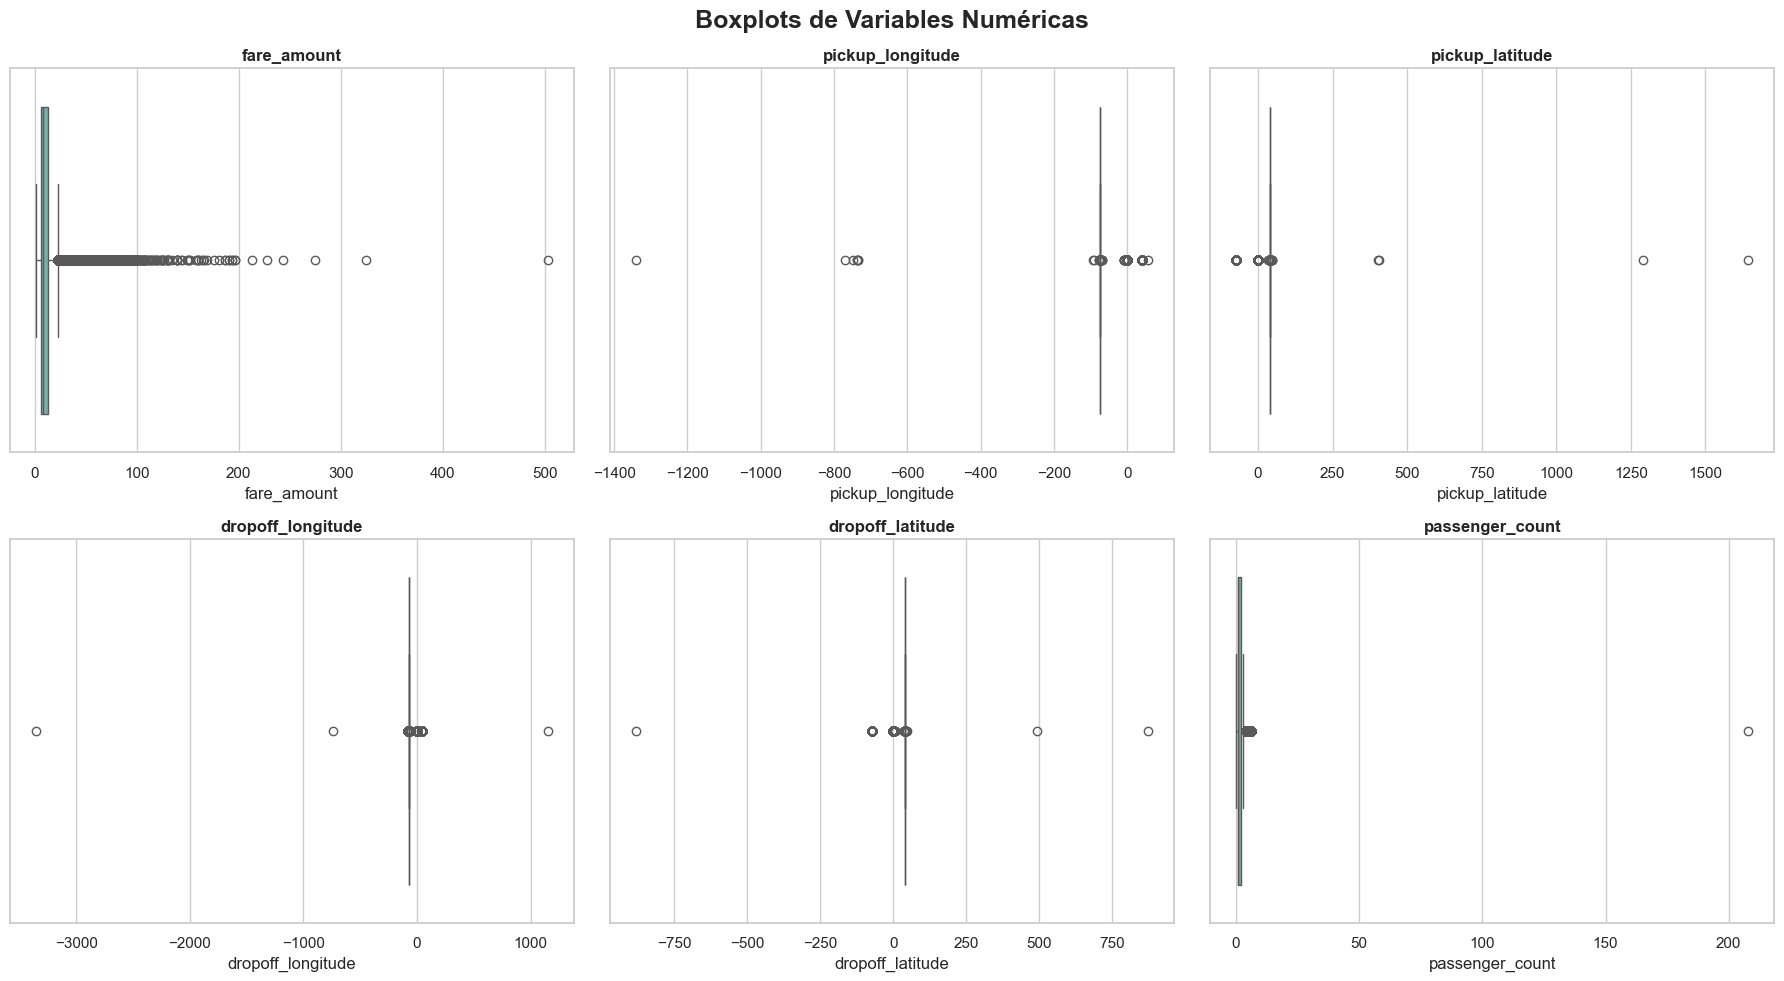

In [14]:
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]

    sns.boxplot(x=df[col], ax=ax, color='#72B7B2')

    ax.set_title(col, fontsize=12, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots de Variables Numéricas',
             fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

Se observa que fare_amount tiene outliers, asi como las demás variables.

### 3.4) **Gestión de datos nulos, duplicados y tipos**

Registros nulos.

In [15]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
                   Nulos  Porcentaje (%)                 Tipo
fare_amount            0          0.0000              float64
pickup_datetime        0          0.0000  datetime64[ns, UTC]
pickup_longitude       0          0.0000              float64
pickup_latitude        0          0.0000              float64
dropoff_longitude      1          0.0005              float64
dropoff_latitude       1          0.0005              float64
passenger_count        0          0.0000                int64

Total de celdas con nulos: 2 (0.0001% del dataset)


In [16]:
df[df.isna().any(axis=1)]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
87946,24.15,2013-07-02 03:53:05+00:00,-73.950581,40.779692,NaN,NaN,0


Al ser solo 1 fila con valor faltante, éste  podria ser MCAR.

Registros duplicados

In [17]:
n_duplicados = df.duplicated().sum()
pct_duplicados = n_duplicados / len(df) * 100

print(f'Registros duplicados: {n_duplicados} ({pct_duplicados:.2f}%)')
print()

if n_duplicados > 0:
    print('Ejemplo de registros duplicados:')
    duplicados = df[df.duplicated(keep=False)].sort_values(by=cols_numericas)
    print(duplicados.head(10))
    print()

    # Decision: conservar duplicados (pueden ser diamantes distintos con mismas specs)
    print('DECISION: Se conservan los duplicados.\n'
          'Justificacion: en un dataset de productos fisicos, es plausible que\n'
          'dos diamantes distintos compartan todas sus caracteristicas medidas.\n'
          'Eliminarlos introduciria sesgo por sub-representacion.')

Registros duplicados: 0 (0.00%)



No hay registros duplicados.

### 3.5) **Pruebas de Normalidad**

Test D’Agostino-Pearson

In [18]:
ALPHA = 0.05

resultados_normalidad = []

for col in cols_numericas:
    datos = df[col].dropna()

    # D'Agostino-Pearson (muestra completa)
    stat_dag, p_dag = stats.normaltest(datos)



    resultados_normalidad.append({
        'Variable': col,
        'DAgostino-K2': stat_dag,
        'DAgostino-p': p_dag,
    })

df_normalidad = pd.DataFrame(resultados_normalidad)
print('Resultados de Pruebas de Normalidad:')
print('=' * 80)
df_normalidad

Resultados de Pruebas de Normalidad:


,Variable,DAgostino-K2,DAgostino-p
0,fare_amount,198427.389969,0.0
1,pickup_longitude,295418.248664,0.0
2,pickup_latitude,685429.272943,0.0
3,dropoff_longitude,715878.934499,0.0
4,dropoff_latitude,311371.926750,0.0
5,passenger_count,432578.498101,0.0


Como **los resultados del test de D’Agostino-Pearson indican un p-value inferior a 0.05** para todas las variables, entonces se rechaza la *Hipótesis Nula de Normalidad*. En consecuencia, se concluye que **ninguna de las variables analizadas sigue una distribución normal.**

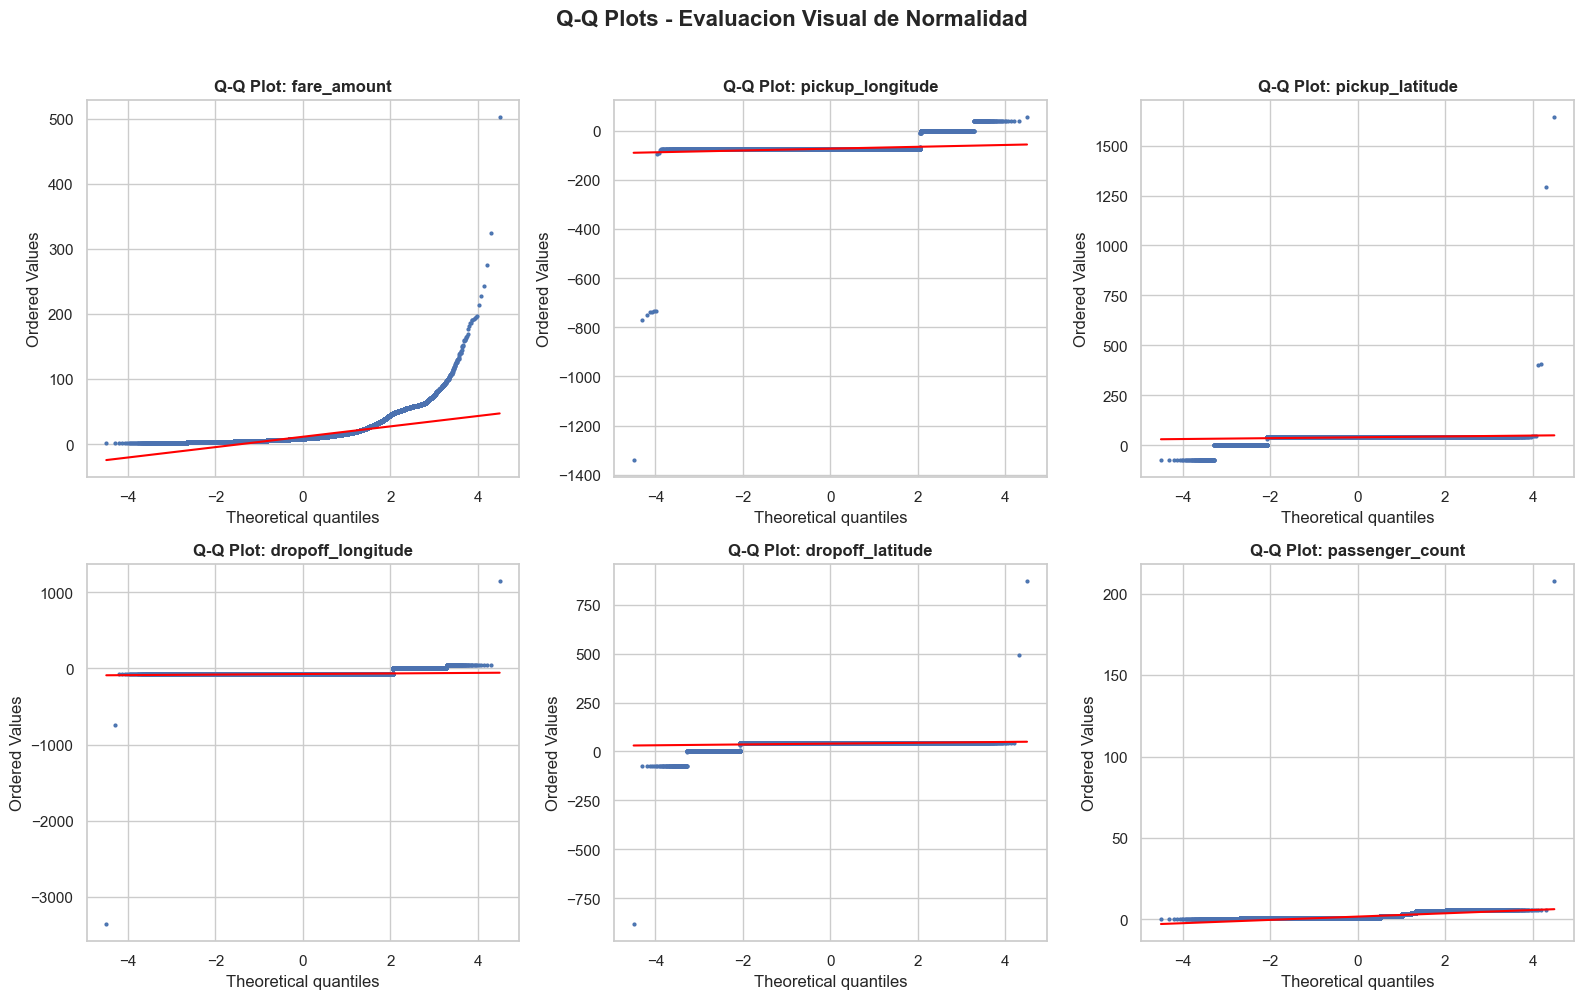

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    datos = df[col].dropna()
    stats.probplot(datos, dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot: {col}', fontweight='bold')
    ax.get_lines()[0].set_markerfacecolor('steelblue')
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[1].set_color('red')

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Q-Q Plots - Evaluacion Visual de Normalidad',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Los puntos no siguen la línea roja, por lo tanto **las variables no son normales**. Además hay outliers (en las variables geográficas se muestra alta concentración de datos y presencia de outliers) y sesgo(fare_amount presenta sesgo positivo). La variable passenger_count, al ser discreta, no puede ajustarse a una distribución normal.

### 3.6) **Correlación y Colinealidad**

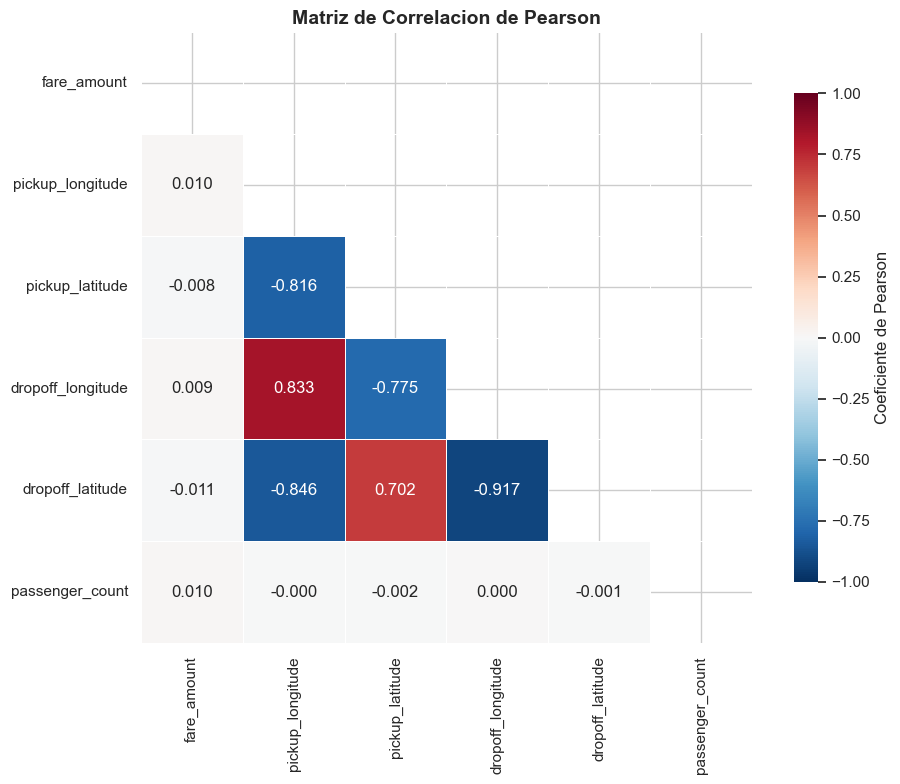

In [20]:
corr_pearson = df[cols_numericas].corr(method='pearson')

# Mascara triangular superior
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Pearson'})
ax.set_title('Matriz de Correlacion de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

La **matriz de correlación de Pearson** muestra que las variables geográficas individuales (latitud y longitud) presentan **correlaciones cercanas a cero** con la variable objetivo fare_amount y passenger_count lo que indica la ausencia de relación lineal directa.

Sin embargo, se observan altas correlaciones entre las coordenadas de origen y destino, es esperable dado que los viajes se realizan dentro de una misma área geográfica.

La información relevante no reside en las coordenadas individuales, sino en la **distancia entre puntos**. Por lo tanto, se propone la creación de una nueva variable que capture dicha distancia, la cual tiene mayor capacidad explicativa sobre la tarifa del viaje.

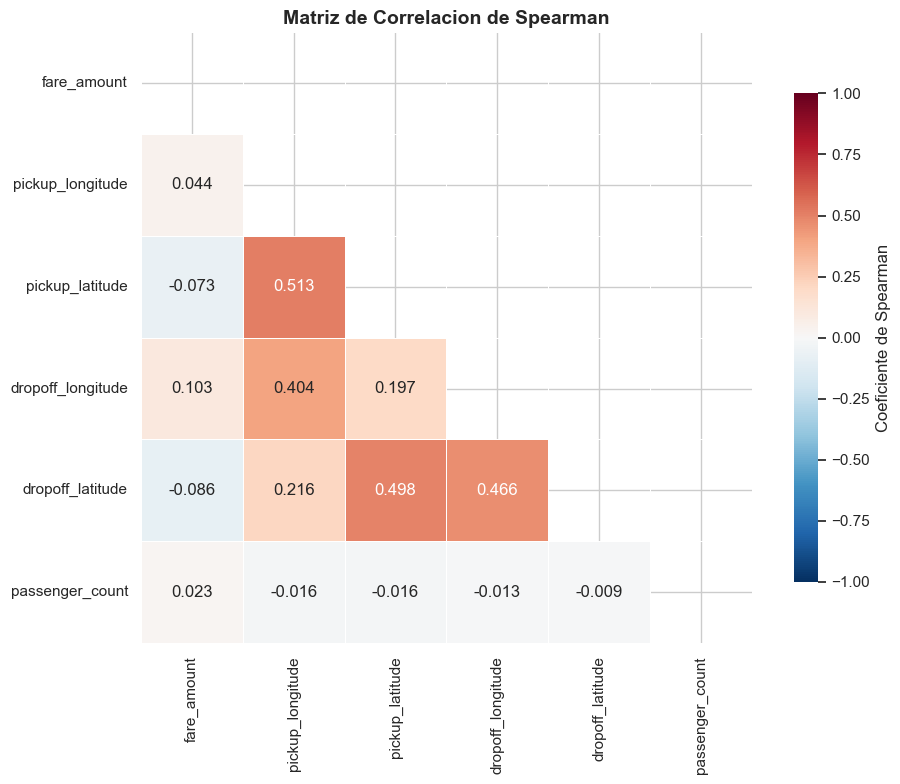

In [21]:
corr_spearman = df[cols_numericas].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Spearman'})
ax.set_title('Matriz de Correlacion de Spearman', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Dado que las variables no cumplen el supuesto de normalidad y presentan valores atípicos, la **correlación de Spearman** resulta más adecuada que Pearson, ya que permite capturar relaciones monótonas no lineales y es más robusta frente a outliers.

En relación con la variable objetivo fare_amount, se observa que presenta correlaciones muy bajas con el resto de las variables. Los coeficientes son cercanos a cero (por ejemplo, 0.044 con pickup_longitude y 0.103 con dropoff_longitude), lo que indica que no existe una relación monotónica significativa entre la tarifa y estas variables de manera individual.

Las variables geográficas muestran correlaciones moderadas entre sí. Existe una correlación positiva moderada entre pickup_latitude y pickup_longitude (0.513).
También se observan correlaciones entre las coordenadas de origen y destino, como entre dropoff_latitude y dropoff_longitude (0.466), y entre pickup_latitude y dropoff_latitude (0.498).

Estas relaciones son esperables, ya que reflejan la estructura espacial de los viajes: puntos de origen y destino tienden a estar relacionados geográficamente.

En cuanto a passenger_count, se observa que no presenta correlación relevante con ninguna de las variables (valores cercanos a cero), lo que sugiere que la cantidad de pasajeros no influye significativamente en la tarifa ni en la ubicación del viaje.

Colinealidad

In [22]:
UMBRAL_COLINEALIDAD = 0.85

print(f'Pares con |r_pearson| >= {UMBRAL_COLINEALIDAD} (posible colinealidad):')
print('=' * 60)

pares_colineales = []
for i in range(len(corr_pearson.columns)):
    for j in range(i + 1, len(corr_pearson.columns)):
        r = corr_pearson.iloc[i, j]
        if abs(r) >= UMBRAL_COLINEALIDAD:
            var1 = corr_pearson.columns[i]
            var2 = corr_pearson.columns[j]
            pares_colineales.append((var1, var2, r))
            print(f'  {var1} <-> {var2}: r = {r:.4f}')

if not pares_colineales:
    print('  No se detectaron pares con colinealidad severa.')
else:
    print(f'\nSe detectaron {len(pares_colineales)} par(es) colineal(es).\n'
          f'Considerar eliminar variables redundantes o usar PCA.')

Pares con |r_pearson| >= 0.85 (posible colinealidad):
  dropoff_longitude <-> dropoff_latitude: r = -0.9170

Se detectaron 1 par(es) colineal(es).
Considerar eliminar variables redundantes o usar PCA.


Se detectó colinealidad entre las variables dropoff_longitude y dropoff_latitude, (-0.917), lo cual indica una fuerte dependencia lineal entre ambas.

Esta situación es esperable dado que ambas variables representan coordenadas geográficas dentro de una misma región, por lo que no son independientes.

Sin embargo, eliminar una de ellas implicaría pérdida de información espacial relevante. Por ello, en lugar de eliminar variables, se propone la creación de una nueva variable que capture la distancia entre origen y destino, reduciendo la redundancia y mejorando la capacidad explicativa del modelo.

In [23]:
from sklearn.linear_model import LinearRegression

# Calcular VIF para variables numericas (sin nulos)
df_vif = df[cols_numericas].dropna()

vif_resultados = []
for col in cols_numericas:
    X = df_vif.drop(columns=[col]).values
    y = df_vif[col].values

    reg = LinearRegression().fit(X, y)
    r2 = reg.score(X, y)

    vif = 1 / (1 - r2) if r2 < 1 else np.inf
    vif_resultados.append({'Variable': col, 'R2': r2, 'VIF': vif})

df_vif_result = pd.DataFrame(vif_resultados).sort_values('VIF', ascending=False)

print('Variance Inflation Factor (VIF):')
print('=' * 50)
print('VIF > 10: colinealidad severa | VIF > 5: colinealidad moderada')
print()

for _, row in df_vif_result.iterrows():
    alerta = '  << SEVERA' if row['VIF'] > 10 else ('  << MODERADA' if row['VIF'] > 5 else '')
    print(f"  {row['Variable']:>8s}: VIF = {row['VIF']:>10.2f}{alerta}")

Variance Inflation Factor (VIF):
VIF > 10: colinealidad severa | VIF > 5: colinealidad moderada

  dropoff_longitude: VIF =       7.98  << MODERADA
  dropoff_latitude: VIF =       7.86  << MODERADA
  pickup_longitude: VIF =       5.36  << MODERADA
  pickup_latitude: VIF =       3.54
  fare_amount: VIF =       1.00
  passenger_count: VIF =       1.00


VIF muestra que las coordenadas están correlacionadas entre sí, es lógico porque representan ubicación. Pero no es un error, y conviene transformarlas en una variable Distancia.

### 3.7) **Detección y Tratamiento de Outliers**

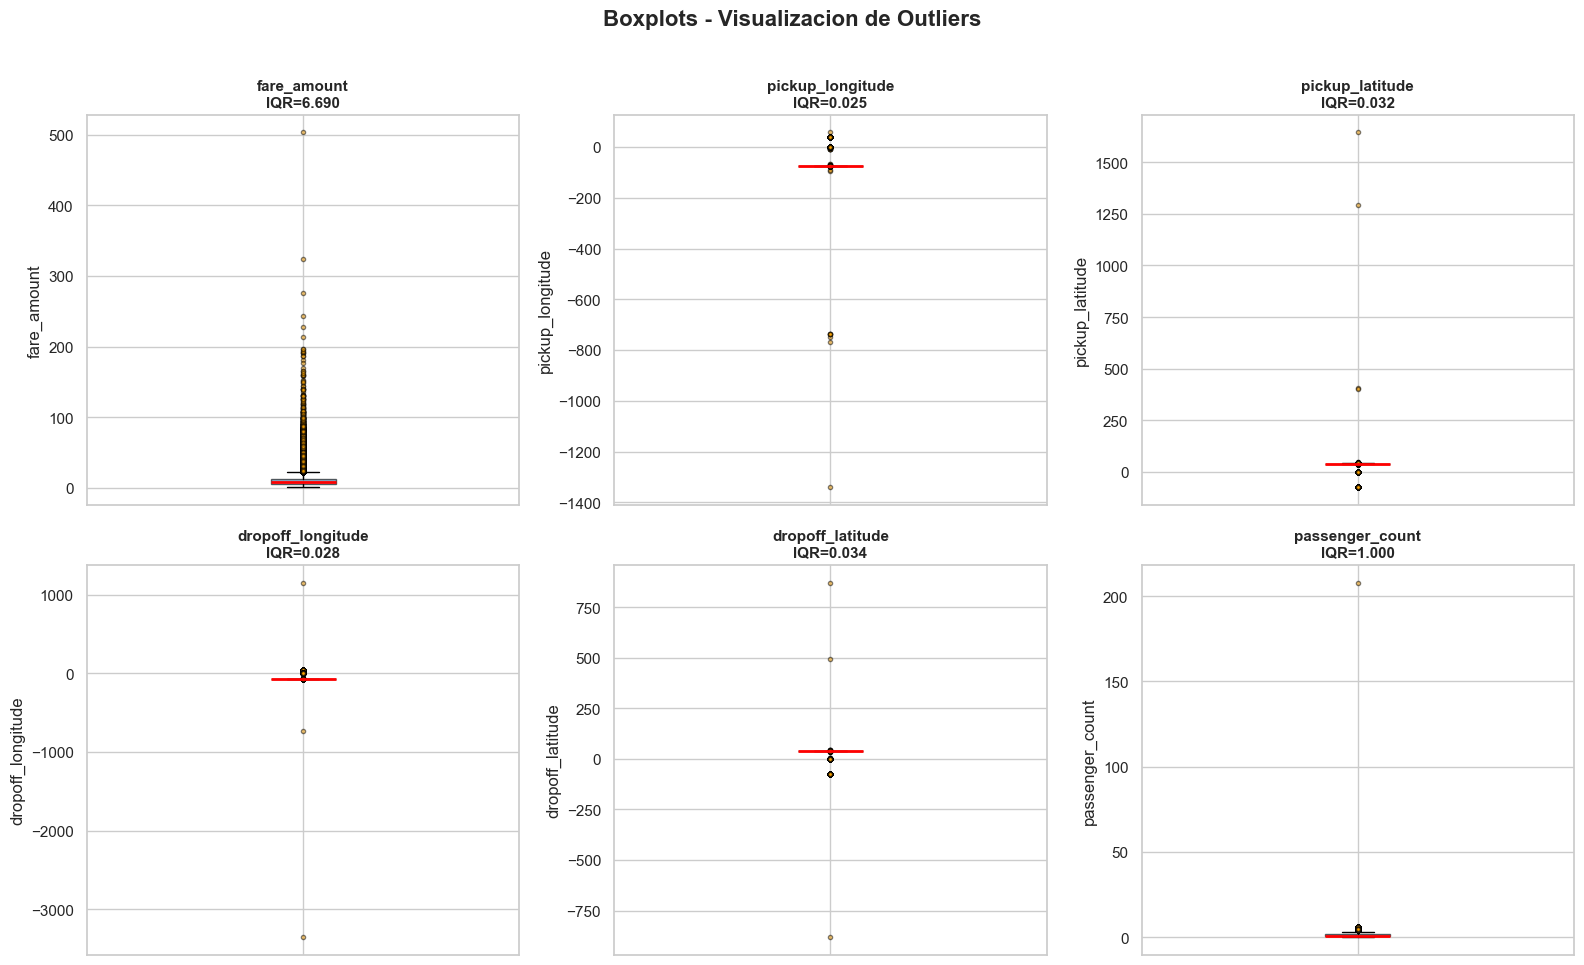

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    datos = df[col].dropna()

    bp = ax.boxplot(datos, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange',
                                    markersize=3, alpha=0.5))

    # Anotaciones de cuartiles
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    ax.set_title(f'{col}\nIQR={iqr:.3f}', fontweight='bold', fontsize=11)
    ax.set_ylabel(col)
    ax.tick_params(axis='x', labelbottom=False)

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Visualizacion de Outliers',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

La variable fare_amount presenta una distribución con una marcada asimetría positiva. La mayor parte de los valores se concentra en un rango bajo, mientras que se observan numerosos outliers hacia valores altos. Esto indica la existencia de viajes con tarifas inusualmente elevadas, que podrían corresponder tanto a casos reales extremos como a errores en los datos.

Las variables geográficas (pickup_longitude, pickup_latitude, dropoff_longitude y dropoff_latitude), se observa que el rango intercuartílico (IQR) es muy reducido, lo que indica una alta concentración de los datos en valores específicos. Sin embargo, aparecen múltiples outliers extremadamente alejados del rango esperado, incluyendo valores imposibles desde el punto de vista geográfico. Esto sugiere la presencia de errores en la recolección o carga de datos, que deben ser corregidos o eliminados.

La variable passenger_count presenta una baja dispersión, con la mayoría de los valores concentrados en pocos pasajeros por viaje. No obstante, se identifican valores atípicos elevados (por ejemplo, cantidades de pasajeros muy superiores a lo razonable), lo cual indica inconsistencias en el dataset.

In [25]:
Z_THRESHOLD = 3.0
IQR_FACTOR = 1.5

reporte_outliers = []

for col in cols_numericas:
    datos = df[col].dropna()
    n = len(datos)

    # Metodo IQR
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    lim_inf_iqr = q1 - IQR_FACTOR * iqr
    lim_sup_iqr = q3 + IQR_FACTOR * iqr
    outliers_iqr = ((datos < lim_inf_iqr) | (datos > lim_sup_iqr)).sum()

    # Metodo Z-Score
    z_scores = np.abs(stats.zscore(datos))
    outliers_zscore = (z_scores > Z_THRESHOLD).sum()

    reporte_outliers.append({
        'Variable': col,
        'N': n,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Lim_Inf_IQR': lim_inf_iqr,
        'Lim_Sup_IQR': lim_sup_iqr,
        'Outliers_IQR': outliers_iqr,
        'Pct_IQR(%)': outliers_iqr / n * 100,
        'Outliers_ZScore': outliers_zscore,
        'Pct_ZScore(%)': outliers_zscore / n * 100
    })

df_outliers = pd.DataFrame(reporte_outliers)

print('Reporte de Outliers: Metodo IQR vs Z-Score')
print('=' * 90)
df_outliers[['Variable', 'N', 'IQR', 'Lim_Inf_IQR', 'Lim_Sup_IQR',
             'Outliers_IQR', 'Pct_IQR(%)', 'Outliers_ZScore', 'Pct_ZScore(%)']]

Reporte de Outliers: Metodo IQR vs Z-Score


,Variable,N,IQR,Lim_Inf_IQR,Lim_Sup_IQR,Outliers_IQR,Pct_IQR(%),Outliers_ZScore,Pct_ZScore(%)
0,fare_amount,200000,6.690000,-4.065000,22.695000,16650,8.325000,5432,2.71600
1,pickup_longitude,200000,0.024911,-74.029432,-73.929786,13559,6.779500,3936,1.96800
2,pickup_latitude,200000,0.032362,40.686252,40.815701,9424,4.712000,3907,1.95350
3,dropoff_longitude,199999,0.027749,-74.033030,-73.922036,14200,7.100036,3901,1.95051
4,dropoff_latitude,199999,0.034178,40.682557,40.819268,12145,6.072530,3887,1.94351
5,passenger_count,200000,1.000000,-0.500000,3.500000,22557,11.278500,4272,2.13600


En todos los casos IQR detecta más outliers que Z-score porque no asume normalidad y es más robusto.

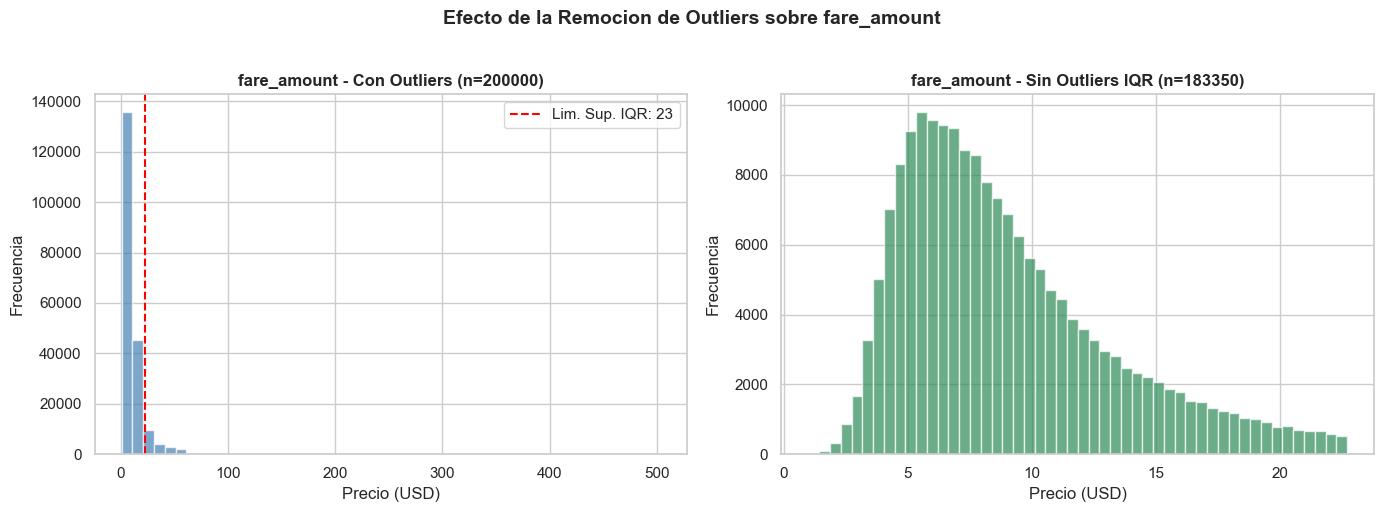

Registros eliminados: 16650 (8.33%)


In [26]:
col_ejemplo = 'fare_amount'
datos = df[col_ejemplo].dropna()

# Limites IQR
q1 = datos.quantile(0.25)
q3 = datos.quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - IQR_FACTOR * iqr
lim_sup = q3 + IQR_FACTOR * iqr

datos_sin_outliers = datos[(datos >= lim_inf) & (datos <= lim_sup)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Con outliers
axes[0].hist(datos, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(lim_sup, color='red', linestyle='--',
                label=f'Lim. Sup. IQR: {lim_sup:.0f}')
axes[0].set_title(f'{col_ejemplo} - Con Outliers (n={len(datos)})',
                  fontweight='bold')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Sin outliers
axes[1].hist(datos_sin_outliers, bins=50, color='seagreen',
             edgecolor='white', alpha=0.7)
axes[1].set_title(f'{col_ejemplo} - Sin Outliers IQR (n={len(datos_sin_outliers)})',
                  fontweight='bold')
axes[1].set_xlabel('Precio (USD)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle(f'Efecto de la Remocion de Outliers sobre {col_ejemplo}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Registros eliminados: {len(datos) - len(datos_sin_outliers)} '
      f'({(len(datos) - len(datos_sin_outliers)) / len(datos) * 100:.2f}%)')

#### Tratamiento de outliers

Visualizamos las subidas y bajadas en un mapa

In [27]:
info_mapeo = df[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']]

In [28]:
import geopandas as gpd
import contextily as ctx

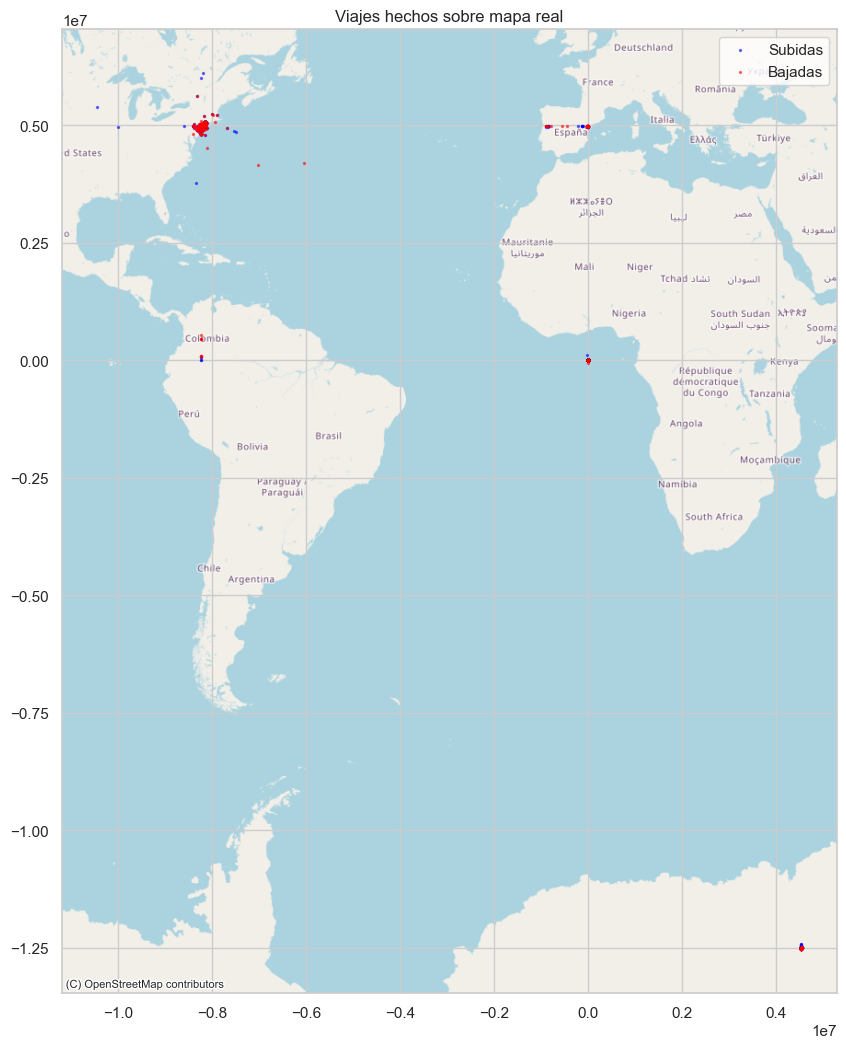

In [29]:
# GeoDataFrame de pickups y dropoffs
gdf_pickup = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(info_mapeo['pickup_longitude'], info_mapeo['pickup_latitude']), crs="EPSG:4326")
gdf_dropoff = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(info_mapeo['dropoff_longitude'], info_mapeo['dropoff_latitude']), crs="EPSG:4326")

# Proyección métrica
gdf_pickup = gdf_pickup.to_crs(epsg=3857)
gdf_dropoff = gdf_dropoff.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 14))
gdf_pickup.plot(ax=ax, markersize=2, color="blue", alpha=0.5, label="Subidas")
gdf_dropoff.plot(ax=ax, markersize=2, color="red", alpha=0.5, label="Bajadas")

# Mapa base
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.legend()
plt.title("Viajes hechos sobre mapa real")
plt.show()

En el mapa observamos que algunos datos estan por fuera de New York.

In [30]:
# Función para definir las coordenadas de New York
def in_ny(lat, lon):
    return 40 <= lat <= 41 and -75 <= lon <= -72

# Filtro pickups
mask_pickup = df.apply(lambda row: in_ny(row['pickup_latitude'], row['pickup_longitude']), axis=1)

# Filtro dropoffs
mask_dropoff = df.apply(lambda row: in_ny(row['dropoff_latitude'], row['dropoff_longitude']), axis=1)

# Se guardan viajes donde pickup y dropoff están en USA
df_ny = df[mask_pickup & mask_dropoff].copy()

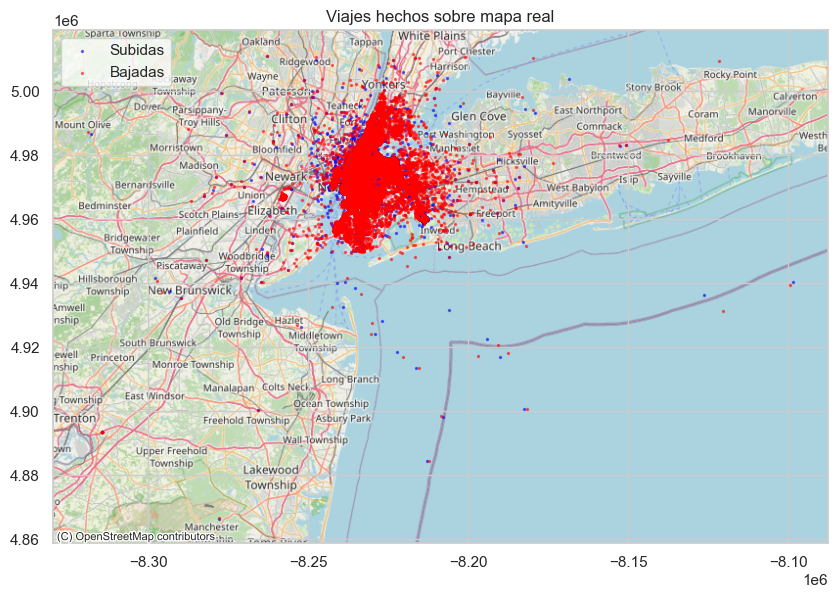

In [31]:
# GeoDataFrame de pickups y dropoffs
gdf_pickup = gpd.GeoDataFrame(df_ny, geometry=gpd.points_from_xy(df_ny['pickup_longitude'], df_ny['pickup_latitude']), crs="EPSG:4326")
gdf_dropoff = gpd.GeoDataFrame(df_ny, geometry=gpd.points_from_xy(df_ny['dropoff_longitude'], df_ny['dropoff_latitude']), crs="EPSG:4326")

# Proyección métrica
gdf_pickup = gdf_pickup.to_crs(epsg=3857)
gdf_dropoff = gdf_dropoff.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 14))
gdf_pickup.plot(ax=ax, markersize=2, color="blue", alpha=0.5, label="Subidas")
gdf_dropoff.plot(ax=ax, markersize=2, color="red", alpha=0.5, label="Bajadas")

# Mapa base
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.legend()
plt.title("Viajes hechos sobre mapa real")
plt.show()


In [32]:
print(f'El dataset original tiene {len(df)} registros. El dataset, tiene {len(df_ny)}. Por lo tanto, se eliminaron {len(df)-len(df_ny)} registros.')

El dataset original tiene 200000 registros. El dataset, tiene 195697. Por lo tanto, se eliminaron 4303 registros.


 Los datos eliminados representan el 2.15% de los datos.

Información sobre daset NY

In [33]:
df_ny.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195697 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   fare_amount        195697 non-null  float64            
 1   pickup_datetime    195697 non-null  datetime64[ns, UTC]
 2   pickup_longitude   195697 non-null  float64            
 3   pickup_latitude    195697 non-null  float64            
 4   dropoff_longitude  195697 non-null  float64            
 5   dropoff_latitude   195697 non-null  float64            
 6   passenger_count    195697 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(5), int64(1)
memory usage: 11.9 MB


Gráficos

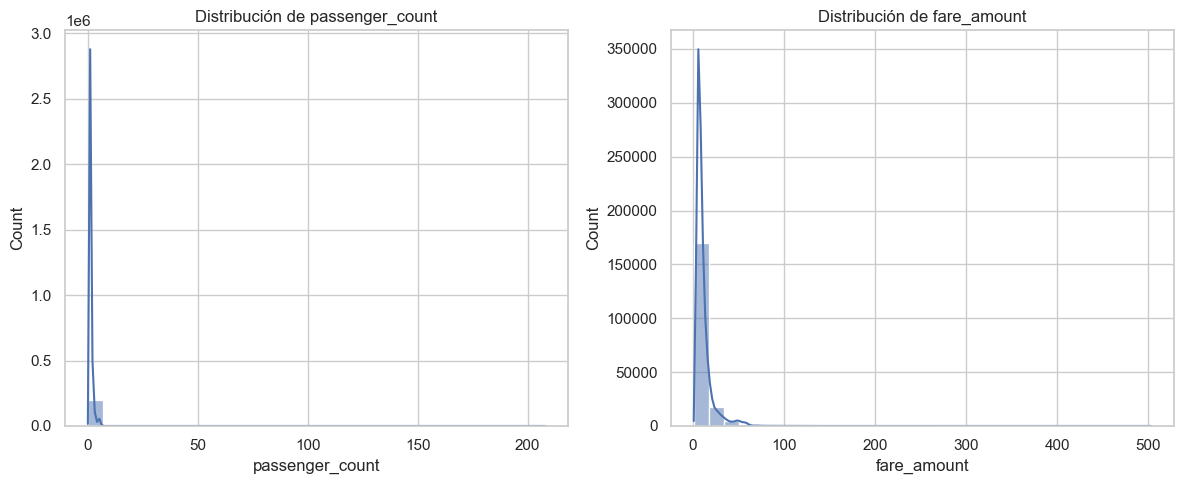

In [34]:
# Gráficos de distribución
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_ny['passenger_count'], bins=30, kde=True)
plt.title('Distribución de passenger_count')

plt.subplot(1, 2, 2)
sns.histplot(df_ny['fare_amount'], bins=30, kde=True)
plt.title('Distribución de fare_amount')

plt.tight_layout()
plt.show()


Las distribuciones son sesgadas a la derecha en ambos casos, con una gran concentración de datos en valores bajos y colas largas hacia valores altos (posibles outliers). Post split, se tendrán en cuenta estos datos para crear nuevas variables o eliminar outliers.

In [35]:
# Eliminamos las filas donde passenger_count es nulo
df_ny = df_ny[df_ny['passenger_count'] <= 6]

Los outliers de passenger_count serán eliminados al ser solo 1 dato se considera que no afectara el trabajo en el dataset.

In [36]:
# Eliminamos las filas donde fare_amount es nulo
df_ny = df_ny.dropna(subset=['fare_amount'])

# Verificamos que ya no existan nulos
print(df_ny.isnull().sum())

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64


Se procedió a eliminar registros nulos de fare_amount en lugar de imputarlos, para evitar introducir sesgos artificiales en el entrenamiento del modelo."

Se eliminan los outliers de fare_amount

In [37]:
Q1 = df_ny["fare_amount"].quantile(0.25)
Q3 = df_ny["fare_amount"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_ny = df_ny[
    (df_ny["fare_amount"] >= limite_inferior) &
    (df_ny["fare_amount"] <= limite_superior)
]

In [38]:
# Info
df_ny.info()

<class 'pandas.core.frame.DataFrame'>
Index: 179457 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   fare_amount        179457 non-null  float64            
 1   pickup_datetime    179457 non-null  datetime64[ns, UTC]
 2   pickup_longitude   179457 non-null  float64            
 3   pickup_latitude    179457 non-null  float64            
 4   dropoff_longitude  179457 non-null  float64            
 5   dropoff_latitude   179457 non-null  float64            
 6   passenger_count    179457 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(5), int64(1)
memory usage: 11.0 MB


### 3.8) **Feature Engineering**

In [39]:
# Se define la función

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

Se crea la variable Distancia en el dataset

In [40]:
df_ny['distance_km'] = haversine(
    df_ny['pickup_latitude'],
    df_ny['pickup_longitude'],
    df_ny['dropoff_latitude'],
    df_ny['dropoff_longitude']
)

In [41]:
# Se verifica
df_ny[['distance_km']].describe()

,distance_km
count,179457.000000
mean,2.527428
std,1.886577
min,0.000000
25%,1.201683
50%,1.994705
75%,3.321255
max,30.779263


Distribucíón de df_ny

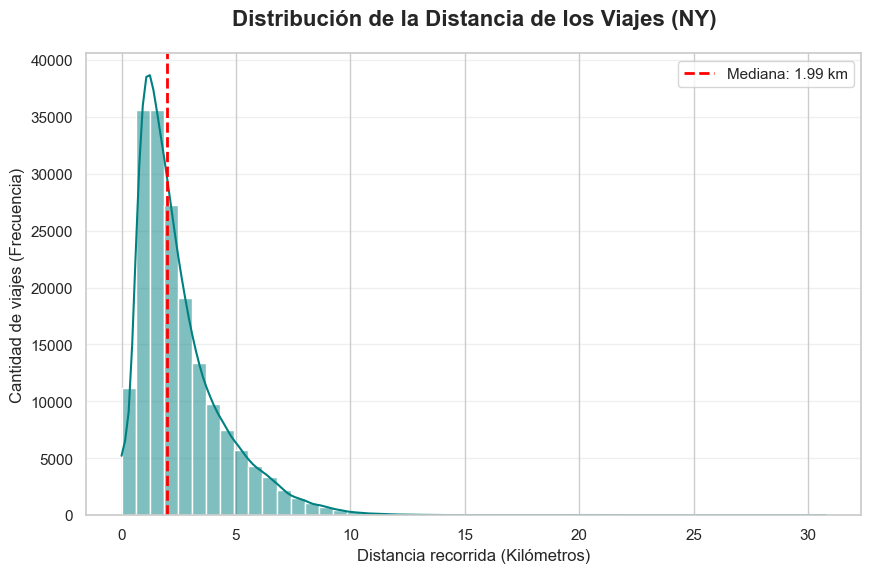

In [42]:
#  Tamaño de la figura
plt.figure(figsize=(10, 6))

# Histograma
sns.histplot(df_ny['distance_km'], bins=50, kde=True, color='teal', edgecolor='white')

# Ejes y titulo del gráfico
plt.title('Distribución de la Distancia de los Viajes (NY)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Distancia recorrida (Kilómetros)', fontsize=12)
plt.ylabel('Cantidad de viajes (Frecuencia)', fontsize=12)

# Información estadística
mediana = df_ny['distance_km'].median()
plt.axvline(mediana, color='red', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.2f} km')

# Leyenda
plt.legend() # Para que se vea la etiqueta de la mediana
plt.grid(axis='y', alpha=0.3) # Una cuadrícula suave ayuda a la lectura
plt.show()

Se creó una nueva variable denominada distance_km, que representa la distancia geográfica entre el punto de origen y destino del viaje.

Para su cálculo se utilizó la fórmula de Haversine, la cual permite medir distancias sobre la superficie terrestre considerando su curvatura.

Esta variable resulta fundamental, ya que la tarifa de un viaje está directamente relacionada con la distancia recorrida, por lo que se espera que tenga un alto poder explicativo en el modelo.

La variable pickup_datetime se encontraba en formato object, por lo que fue convertida a tipo datetime. Esto permite extraer información temporal relevante, como hora del día y día de la semana.

In [43]:
df_ny['pickup_datetime'] = pd.to_datetime(df_ny['pickup_datetime'], utc=True)

In [44]:
df_ny['hour'] = df_ny['pickup_datetime'].dt.hour
df_ny['day'] = df_ny['pickup_datetime'].dt.day
df_ny['month'] = df_ny['pickup_datetime'].dt.month
df_ny['day_of_week'] = df_ny['pickup_datetime'].dt.dayofweek  # 0=Lunes

Se analiza si la hora influye en la tarifa

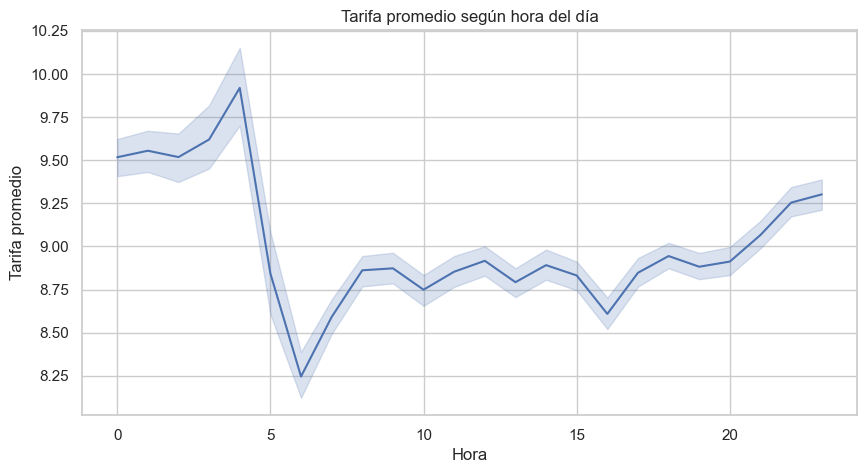

In [45]:
# Promedio de tarifa por hora

plt.figure(figsize=(10,5))
sns.lineplot(x='hour', y='fare_amount', data=df_ny, estimator='mean')
plt.title('Tarifa promedio según hora del día')
plt.xlabel('Hora')
plt.ylabel('Tarifa promedio')
plt.show()

Las tarifas no son constantes a lo largo del día:

Son más altas en la madrugada (0:00-4:00), posiblemente por menor disponibilidad de vehículos o mayor demanda puntual.
Son más bajas en horarios madrugada (6:00) y el resto del día podría ser constante.

Esto sugiere que la hora del día influye en el precio del viaje, por lo que puede ser una variable útil para el modelo.

In [46]:
def grupo_horario(h):
    if 0 <= h <= 4:
        return 'madrugada_alta'
    elif h == 5:
        return 'madrugada_baja'
    else:
        return 'resto_dia'

df_ny['grupo_horario'] = df_ny['hour'].apply(grupo_horario)

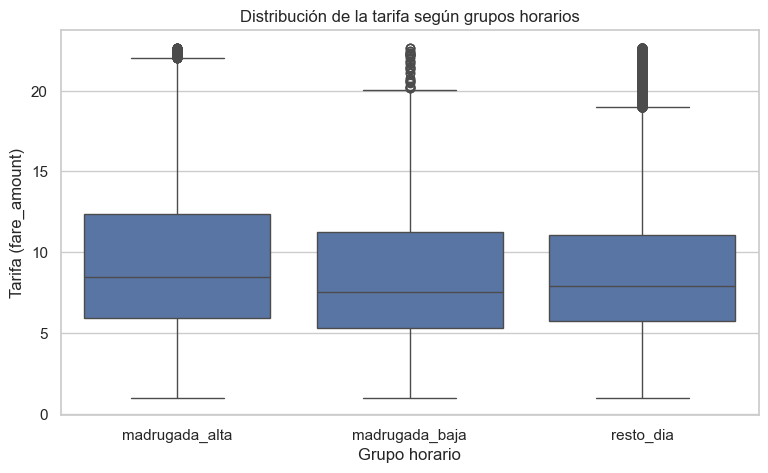

In [47]:
orden = ['madrugada_alta', 'madrugada_baja', 'resto_dia']

plt.figure(figsize=(9,5))
sns.boxplot(x='grupo_horario', y='fare_amount', data=df_ny, order=orden)

plt.title('Distribución de la tarifa según grupos horarios')
plt.xlabel('Grupo horario')
plt.ylabel('Tarifa (fare_amount)')

plt.show()

El grupo madrugada_alta (0:00-4:00) presenta valores de tarifa más elevados, con una mediana superior respecto a los demás grupos.

El grupo madrugada_baja (5:00) muestra una disminución notable en la tarifa, evidenciando un comportamiento diferenciado.

El grupo resto_dia presenta una distribución más estable, con menor variabilidad en comparación con los otros grupos.

Estos resultados validan la creación de la variable grupo_horario, ya que permite capturar patrones relevantes en la tarifa asociados al momento del día.

 Se analiza Dia de la semana

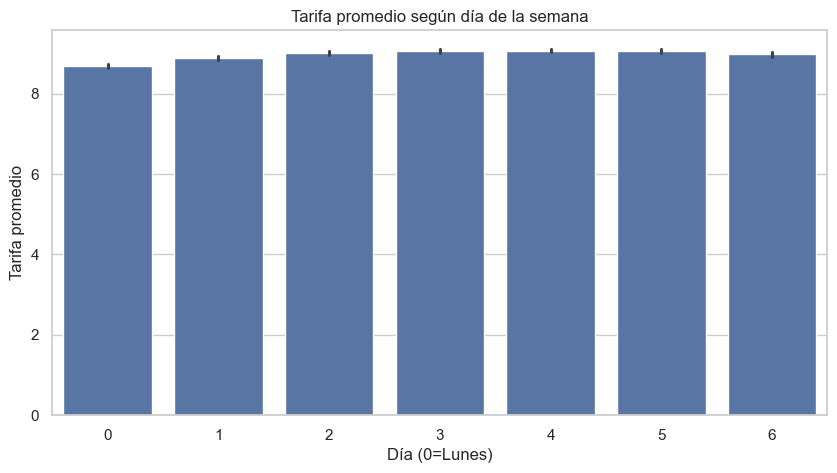

In [48]:
plt.figure(figsize=(10,5))
sns.barplot(x='day_of_week', y='fare_amount', data=df_ny, estimator='mean')
plt.title('Tarifa promedio según día de la semana')
plt.xlabel('Día (0=Lunes)')
plt.ylabel('Tarifa promedio')
plt.show()

En el gráfico se observa que los valores promedio de la tarifa son muy similares para todos los días, sin diferencias significativas entre ellos.

Esto indica que el día de la semana no influye de manera relevante en la tarifa del viaje.

En consecuencia, se decidió no incluir esta variable en el modelo, ya que no aporta capacidad predictiva.

Analizamos si las zonas influyen en la tarifa

In [49]:
# Crea zonas
df_ny['zona'] = pd.cut(df_ny['pickup_latitude'], bins=4).astype(str) + "_" + \
                pd.cut(df_ny['pickup_longitude'], bins=4).astype(str)

In [50]:
# Agrupa distancias
df_ny['dist_bin'] = pd.cut(df_ny['distance_km'], bins=5)

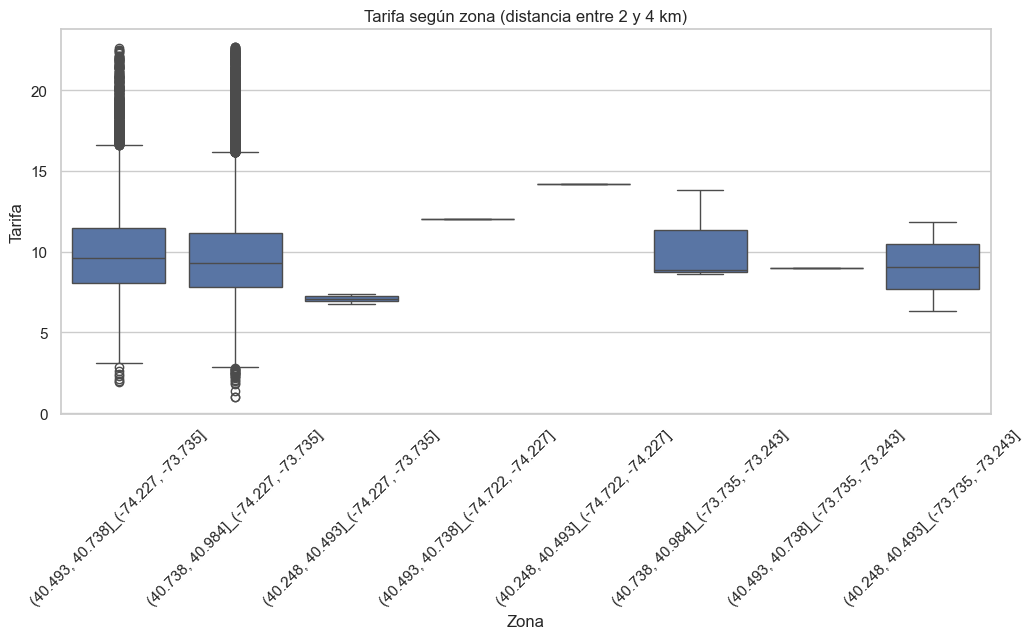

In [51]:
# Comparamos viajes de distancia similar
df_temp = df_ny[(df_ny['distance_km'] > 2) & (df_ny['distance_km'] < 4)]

plt.figure(figsize=(12,5))
sns.boxplot(x='zona', y='fare_amount', data=df_temp)

plt.title('Tarifa según zona (distancia entre 2 y 4 km)')
plt.xlabel('Zona')
plt.ylabel('Tarifa')

plt.xticks(rotation=45)
plt.show()

Se analizó la relación entre la tarifa y la ubicación geográfica, controlando por distancia recorrida.

Para ello, se agruparon los datos en rangos de distancia y zonas geográficas definidas a partir de coordenadas.

Se observó que, para distancias similares, la tarifa varía según la zona, lo que indica que la ubicación influye en el costo del viaje.

Esto sugiere la presencia de factores adicionales como tráfico, demanda o características del área.

In [52]:
df_ny['zona'].value_counts()

zona
(40.738, 40.984]_(-74.227, -73.735]    131863
(40.493, 40.738]_(-74.227, -73.735]     47529
(40.493, 40.738]_(-73.735, -73.243]        15
(40.738, 40.984]_(-73.735, -73.243]        14
(40.001, 40.248]_(-74.722, -74.227]         9
(40.493, 40.738]_(-74.722, -74.227]         8
(40.248, 40.493]_(-74.227, -73.735]         6
(40.248, 40.493]_(-73.735, -73.243]         3
(40.738, 40.984]_(-74.722, -74.227]         3
(40.001, 40.248]_(-73.735, -73.243]         2
(40.738, 40.984]_(-73.243, -72.75]          1
(40.248, 40.493]_(-73.243, -72.75]          1
(40.248, 40.493]_(-74.722, -74.227]         1
(40.001, 40.248]_(-74.227, -73.735]         1
(40.493, 40.738]_(-73.243, -72.75]          1
Name: count, dtype: int64

Se intentó incorporar la variable espacial mediante la creación de zonas geográficas a partir de las coordenadas de origen.

Sin embargo, al analizar la distribución de observaciones por zona, se detectó un fuerte desbalance, con algunas zonas concentrando la gran mayoría de los datos y otras con muy pocas observaciones.

Esta distribución desigual dificulta la comparación entre zonas y puede generar sesgos en el modelo, por lo que se decidió no incluir esta variable en su forma actual.

Eliminamos las variables que no son relevantes

In [53]:
cols_drop = [
    'pickup_datetime',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'hour', 'day', 'month', 'day_of_week',
    'zona',
    'dist_bin'
]

df_ny = df_ny.drop(columns=cols_drop)

Verificamos el dataset

In [54]:
df_ny.info()

<class 'pandas.core.frame.DataFrame'>
Index: 179457 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   fare_amount      179457 non-null  float64
 1   passenger_count  179457 non-null  int64  
 2   distance_km      179457 non-null  float64
 3   grupo_horario    179457 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 6.8+ MB


### 3.9) **Division del dataset en Train y Test**

In [55]:
X = df_ny.drop(columns=['fare_amount'])
y = df_ny['fare_amount']

In [56]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [57]:
print(f'Tamaño de X_train {X_train.shape}; tamaño de X_test: {X_test.shape}')

Tamaño de X_train (143565, 3); tamaño de X_test: (35892, 3)


In [58]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 143565 entries, 136551 to 135928
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   passenger_count  143565 non-null  int64  
 1   distance_km      143565 non-null  float64
 2   grupo_horario    143565 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 4.4+ MB


### 3.10) **One Hot Encoding**

In [59]:
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

In [60]:
# Se aplica a Train
X_train_cat = ohe.fit_transform(X_train[['grupo_horario']])
X_test_cat = ohe.transform(X_test[['grupo_horario']])

In [61]:
# Se convierte a Dataframe
cols = ohe.get_feature_names_out(['grupo_horario'])

X_train_cat = pd.DataFrame(X_train_cat, columns=cols, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_cat, columns=cols, index=X_test.index)

In [62]:
# Se une a las variables numéricas
X_train = pd.concat([X_train.drop(columns=['grupo_horario']), X_train_cat], axis=1)
X_test = pd.concat([X_test.drop(columns=['grupo_horario']), X_test_cat], axis=1)

In [63]:
X_train.columns

Index(['passenger_count', 'distance_km', 'grupo_horario_madrugada_baja',
       'grupo_horario_resto_dia'],
      dtype='object')

In [64]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 143565 entries, 136551 to 135928
Data columns (total 4 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   passenger_count               143565 non-null  int64  
 1   distance_km                   143565 non-null  float64
 2   grupo_horario_madrugada_baja  143565 non-null  float64
 3   grupo_horario_resto_dia       143565 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 5.5 MB


### 3.11) **Matriz de Correlación**

In [65]:
# Generación de la matriz de correlación de Spearman
df_corr = X_train.copy()
df_corr['fare_amount'] = y_train

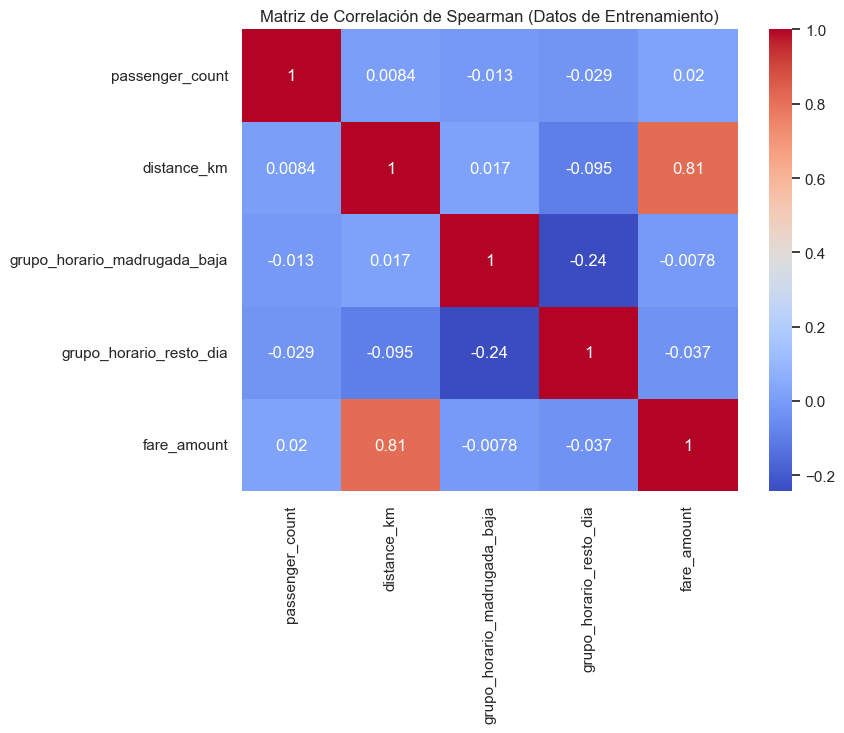

In [66]:
plt.figure(figsize=(8,6))
sns.heatmap(df_corr.corr(method='spearman'), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación de Spearman (Datos de Entrenamiento)')
plt.show()

A partir de la matriz de correlación, se observa que la variable distance_km presenta una fuerte correlación positiva con la variable objetivo fare_amount , lo cual indica que la distancia es el principal determinante del costo del viaje.

Por otro lado, variables como passenger_count y las variables derivadas del horario presentan correlaciones cercanas a cero, lo que sugiere una baja influencia en la tarifa.

Esto refuerza la decisión de incluir la distancia como variable principal en el modelo, mientras que las demás variables aportan información adicional limitada.

Si bien en el análisis exploratorio se observó que durante la madrugada las tarifas promedio eran más elevadas, el análisis de correlación muestra que las variables horarias tienen una baja relación directa con la tarifa.

Esto sugiere que el efecto observado inicialmente podría estar influenciado por otras variables, como la distancia del viaje, y no por el horario en sí mismo

### 3.12) **Estandarización**

In [67]:
scaler = RobustScaler()

In [68]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [69]:
# escalamos las variables numéricas, no ohe
num_cols = ['distance_km', 'passenger_count']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

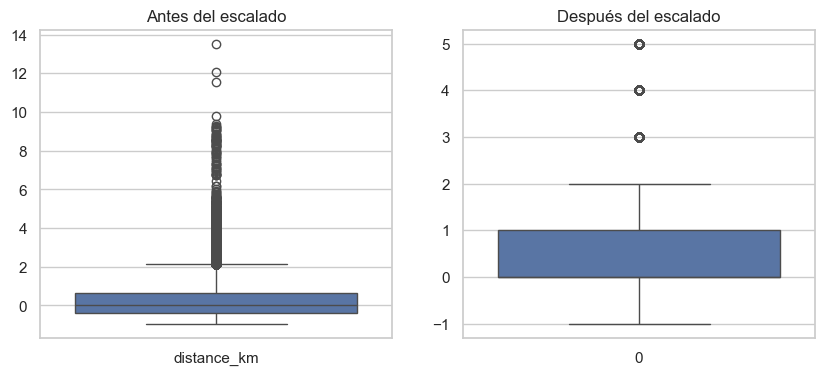

In [70]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(data=X_train[['distance_km']])
plt.title('Antes del escalado')

plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled[:,0].reshape(-1,1))
plt.title('Después del escalado')

plt.show()

Se aplicó un escalado de variables mediante RobustScaler, con el objetivo de reducir el impacto de valores atípicos. Este proceso permite mejorar el rendimiento de modelos sensibles a la escala de los datos.

### 3.13) **Validación cruzada**

In [71]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()

scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_mean_squared_error'
)

In [72]:
# RMSE

rmse_scores = np.sqrt(-scores)

print("RMSE por fold:", rmse_scores)
print("RMSE promedio:", rmse_scores.mean())

RMSE por fold: [2.52929912 2.57632712 2.58725877 2.65646067 2.57679737]
RMSE promedio: 2.585228611264985


Se aplicó validación cruzada con 5 particiones para evaluar el desempeño del modelo.
Se obtuvo un RMSE promedio de 2.58, lo que indica que el modelo presenta un error medio de aproximadamente 2.58 unidades monetarias en la predicción de la tarifa.

Además, los valores obtenidos en cada partición son consistentes entre sí, lo que sugiere que el modelo es estable y generaliza adecuadamente.

## 4) **Regresión Lineal Múltiple**

### 4.1) **Entrenamiento de Modelos de Regresión Lineal**

In [73]:
# Modelo base
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [74]:
# Predicciones
y_train_pred = model_lr.predict(X_train_scaled)
y_test_pred = model_lr.predict(X_test_scaled)

In [75]:
# Métricas
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

def metricas(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

print("Train:", metricas(y_train, y_train_pred))
print("Test:", metricas(y_test, y_test_pred))

Train: {'RMSE': np.float64(2.585265807135419), 'R2': 0.6281469596458822, 'MAE': 1.8199109496867953}
Test: {'RMSE': np.float64(2.6065806187637794), 'R2': 0.6161048150760675, 'MAE': 1.8180603990885167}


### 4.2) **Gradiente descendiente**

Batch

In [76]:
def batch_gradient_descent_adaptado(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):
    """
    Implementa el Descenso de Gradiente por Lotes (BGD) para Regresión Lineal.
    Usa X_test/y_test para monitorear el error de generalización.

    Las variables de entrada se convierten a NumPy y se ajusta la forma (n, 1) internamente.
    """

    # Convertir a NumPy array
    X_train = np.array(X_train)
    X_test = np.array(X_test)

    # Asegurar que las etiquetas y sean vectores columna (n, 1)
    y_train = np.array(y_train).reshape(-1, 1)
    y_test = np.array(y_test).reshape(-1, 1)

    # Obtener shapes
    n = X_train.shape[0]
    m = X_train.shape[1]
    p = X_test.shape[0]

    X_train_b = np.hstack((np.ones((n, 1)), X_train))
    X_test_b = np.hstack((np.ones((p, 1)), X_test))

    # Inicializar pesos aleatorios
    W = np.random.randn(m + 1).reshape(m + 1, 1)

    train_errors = []
    test_errors = []

    # Entrenamiento (Épocas)
    for _ in range(epochs):
        # A. Predicción y Error de Entrenamiento
        prediction_train = np.matmul(X_train_b, W)

        error_train = y_train - prediction_train
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # B. Predicción y Error de Prueba (Monitoreo)
        prediction_test = np.matmul(X_test_b, W)
        error_test = y_test - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        # C. Calcular el Gradiente (usando el lote completo)
        grad_sum = np.sum(error_train * X_train_b, axis=0)
        grad_mul = -2/n * grad_sum
        gradient = grad_mul.reshape(-1, 1)

        W = W - (lr * gradient)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de Entrenamiento (MSE)')
    plt.plot(test_errors, label='Error de Prueba (MSE)')
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title(f'Error de Entrenamiento y Prueba vs. Iteraciones (BGD, lr={lr})')
    plt.grid(True)
    plt.show()

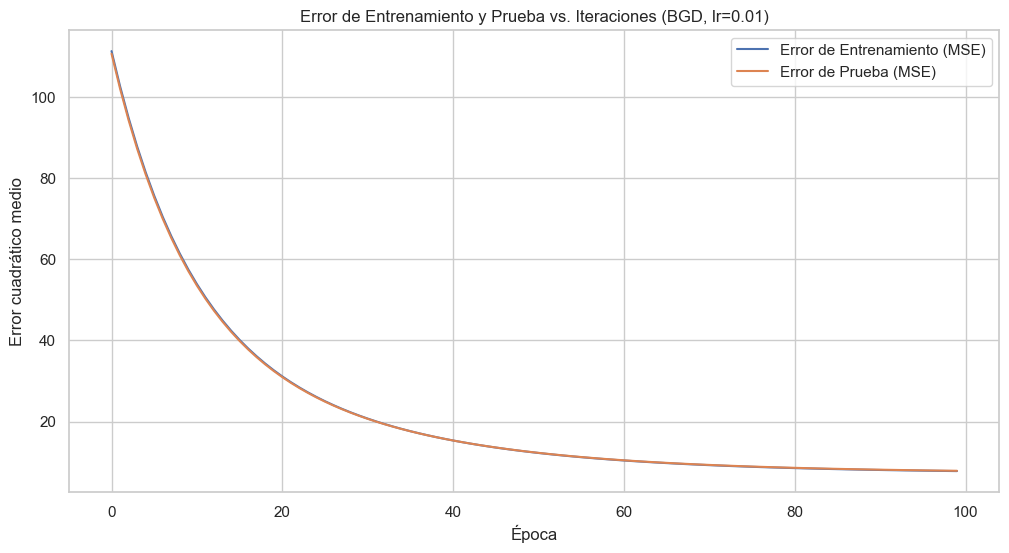

In [77]:
batch_gradient_descent_adaptado(X_train, y_train, X_test, y_test)

El (MSE) disminuye progresivamente a lo largo de las épocas, pasando de valores cercanos a 140 a aproximadamente 100. Además, las curvas de entrenamiento y prueba se mantienen prácticamente superpuestas, lo que indica una buena capacidad de generalización y ausencia de sobreajuste. Estos resultados sugieren que el modelo converge de manera estable y adecuada.
La cercanía entre ambas curvas sugiere que el modelo presenta un buen equilibrio entre sesgo y varianza.

El conjunto de prueba se utiliza únicamente para monitorear el comportamiento del modelo durante el entrenamiento, no para ajustar los parámetros (evitamos dataleakage).

Stochastic

In [78]:
def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):
    """
    Implementa el Descenso de Gradiente Estocástico (SGD) para Regresión Lineal.
    Usa un solo ejemplo aleatorio para cada actualización.
    """

    X_train = np.array(X_train)
    X_test = np.array(X_test)

    y_train = np.array(y_train).reshape(-1, 1)
    y_test = np.array(y_test).reshape(-1, 1)

    n = X_train.shape[0]
    m = X_train.shape[1]

    # 2. Agregar Bias Trick
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    # 3. Inicializar pesos
    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors_plot = []
    test_errors_plot = []

    for i in range(epochs):
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        # Lista para almacenar los MSEs de cada ejemplo dentro de la época
        epoch_train_mse = []

        for j in range(n):
            x_sample = X_train[j].reshape(1, -1)
            y_sample = y_train[j].reshape(1, -1)

            # A. Predicción y Error (con un solo dato)
            prediction = np.matmul(x_sample, W)
            error = y_sample - prediction

            # El MSE para un punto es solo el error al cuadrado:
            mse_sample = error ** 2
            epoch_train_mse.append(mse_sample[0, 0])

            # B. Cálculo de Gradiente y Actualización
            gradient = -2 * error * x_sample.T

            W = W - (lr * gradient)

        # C. Monitoreo (Una vez por Época)
        train_errors_plot.append(np.mean(epoch_train_mse))

        # 2. Error de Prueba
        prediction_test = np.matmul(X_test, W)
        error_test = y_test - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors_plot.append(test_mse)


    plt.figure(figsize=(12, 6))
    plt.plot(train_errors_plot, label='Error de Entrenamiento (MSE)')
    plt.plot(test_errors_plot, label='Error de Prueba (MSE)')
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title(f'Error de Entrenamiento y Prueba vs. Épocas (SGD, lr={lr})')
    plt.grid(True)
    plt.show()

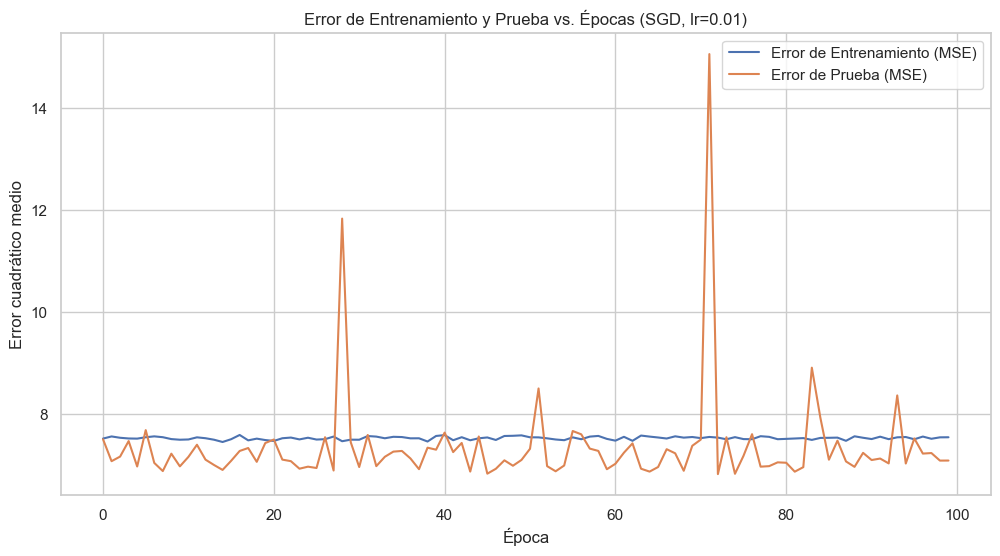

In [79]:
stochastic_gradient_descent(X_train, y_train, X_test, y_test)

En el caso del descenso de gradiente estocástico, el error de entrenamiento se mantiene bajo y estable, mientras que el error de prueba presenta valores generalmente bajos pero con picos elevados en ciertas épocas. Este comportamiento es característico del SGD, debido a que las actualizaciones se realizan utilizando una sola observación, lo que introduce variabilidad en el proceso de optimización. Si bien el modelo logra un buen rendimiento promedio, la presencia de oscilaciones indica menor estabilidad en comparación con el método batch.

Minibatch

In [80]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=64):
    """
    Implementa Mini-Batch GD para Regresión Lineal.
    Actualiza los pesos usando un subconjunto de datos (mini-lote) en cada iteración.
    """
    X_train = np.array(X_train)
    X_test = np.array(X_test)
    y_train = np.array(y_train).reshape(-1, 1) # Asegura la forma (n, 1)
    y_test = np.array(y_test).reshape(-1, 1)

    n = X_train.shape[0]
    m = X_train.shape[1]

    # 2. Agregar Bias Trick
    X_train_b = np.hstack((np.ones((n, 1)), X_train))
    X_test_b = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors_plot = []
    test_errors_plot = []

    for i in range(epochs):
        permutation = np.random.permutation(n)
        X_shuffled = X_train_b[permutation]
        y_shuffled = y_train[permutation]

        epoch_train_mse = []

        # 3. Iterar sobre los mini-lotes
        for j in range(0, n, batch_size):
            # Obtener el mini-lote
            x_batch = X_shuffled[j:j+batch_size, :]
            y_batch = y_shuffled[j:j+batch_size] # Ya es (n_batch, 1)

            # A. Cálculo del Error y Predicción
            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction

            # Monitoreo del error del mini-lote
            mse_batch = np.mean(error ** 2)
            epoch_train_mse.append(mse_batch)


            gradient = -2 * np.matmul(x_batch.T, error) / batch_size
            W = W - (lr * gradient)

        #Monitoreo por Época (Cruce de Validación)

        # Error de Entrenamiento (Promedio de todos los mini-lotes vistos en la época)
        train_errors_plot.append(np.mean(epoch_train_mse))

        # Error de Prueba (Evaluado con los pesos actuales W sobre todo X_test)
        prediction_test = np.matmul(X_test_b, W)
        error_test = y_test - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors_plot.append(test_mse)


    plt.figure(figsize=(12, 6))
    plt.plot(train_errors_plot, label='Error de Entrenamiento (MSE)')
    plt.plot(test_errors_plot, label='Error de Prueba (MSE)')
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title(f'Error de Entrenamiento y Prueba vs. Épocas (Mini-Batch GD, size={batch_size}, lr={lr})')
    plt.grid(True)
    plt.show()

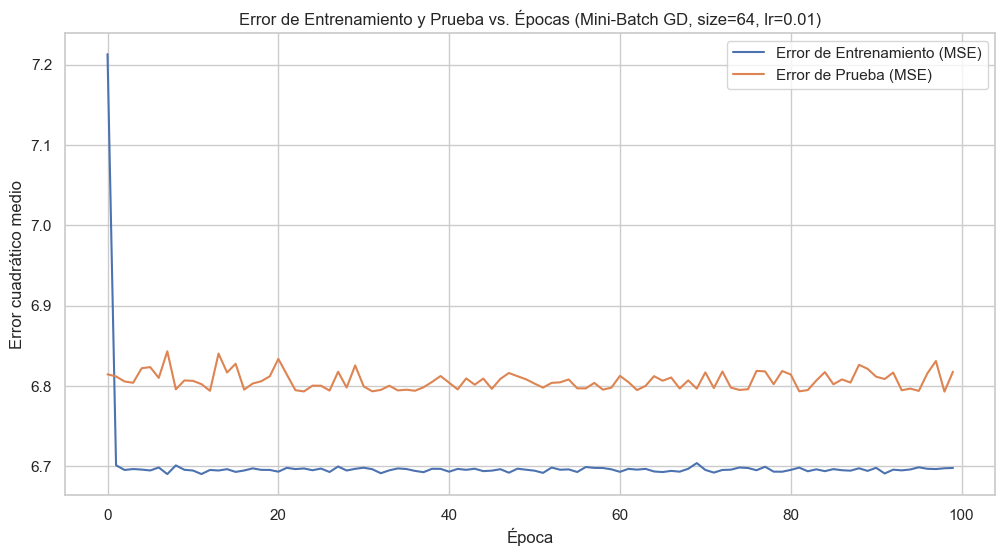

In [81]:
mini_batch_gradient_descent(X_train, y_train, X_test, y_test)

El modelo aprende muy rápido al inicio y alcanza rápidamente un mínimo. Después, entra en una fase de convergencia, donde ya no mejora significativamente.
La cercanía entre el error de entrenamiento (aprox 6.7) y el de prueba (aprox 6.8) sugiere una buena capacidad de generalización y ausencia de sobreajuste.

Los pequeños picos en el error de prueba son esperables en este método, debido a que Mini-batch introduce cierta variabilidad (ruido) en las actualizaciones,

Conclusión:

El método Batch presenta una convergencia estable y sin oscilaciones, aunque con mayor costo computacional.
El método Stochastic introduce alta variabilidad en el error, evidenciada por picos pronunciados, lo que refleja menor estabilidad.
El método Mini-Batch logra un equilibrio adecuado, mostrando una convergencia rápida, errores bajos y oscilaciones controladas.

En base a estos resultados, se concluye que el método de Mini-Batch Gradient Descent resulta el más adecuado, ya que combina eficiencia computacional con estabilidad en el proceso de entrenamiento.

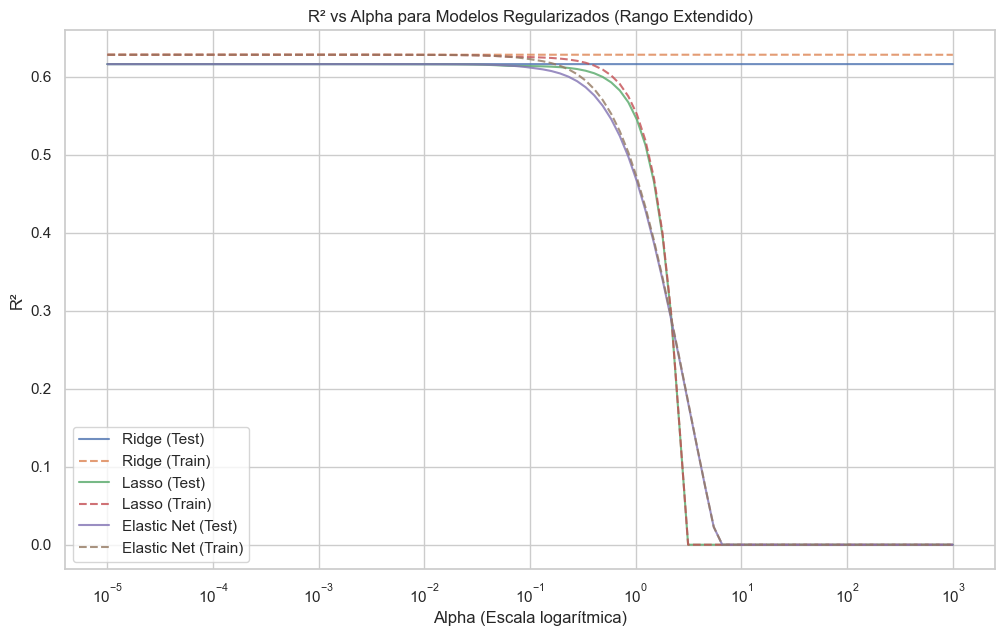

In [82]:
alphas = np.logspace(-5, 3, 100)
results = []

for alpha in alphas:
    
    # RIDGE
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)
    
    # LASSO
    lasso_model = Lasso(alpha=alpha, max_iter=10000)
    lasso_model.fit(X_train, y_train)
    
    # ELASTIC NET
    elastic_net_model = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=10000)
    elastic_net_model.fit(X_train, y_train)


    modelos = [('Ridge', ridge_model), ('Lasso', lasso_model), ('Elastic Net', elastic_net_model)]

    for nombre, modelo in modelos:
        
        # A. EVALUACIÓN EN CONJUNTO DE PRUEBA (TEST)
        y_pred_test = modelo.predict(X_test)
        results.append({
            "Modelo": nombre, "Alpha": alpha, "Conjunto": "test",
            "R2": r2_score(y_test, y_pred_test),
            "MSE": mean_squared_error(y_test, y_pred_test)
        })

        # B. EVALUACIÓN EN CONJUNTO DE ENTRENAMIENTO (TRAIN)
        y_pred_train = modelo.predict(X_train)
        results.append({
            "Modelo": nombre, "Alpha": alpha, "Conjunto": "train",
            "R2": r2_score(y_train, y_pred_train),
            "MSE": mean_squared_error(y_train, y_pred_train)
        })

df_results = pd.DataFrame(results)

## Gráfico de R² vs Alpha con los tres modelos
plt.figure(figsize=(12,7))
for model_name in ['Ridge','Lasso', 'Elastic Net']:
    # Graficar rendimiento de Prueba (Test)
    subset_test = df_results[(df_results['Modelo']==model_name) & (df_results['Conjunto']=='test')]
    plt.plot(subset_test['Alpha'], subset_test['R2'], label=f"{model_name} (Test)", linestyle='-', alpha=0.8)

    # Graficar rendimiento de Entrenamiento (Train)
    subset_train = df_results[(df_results['Modelo']==model_name) & (df_results['Conjunto']=='train')]
    plt.plot(subset_train['Alpha'], subset_train['R2'], label=f"{model_name} (Train)", linestyle='--', alpha=0.8)

plt.xscale('log')
plt.xlabel("Alpha (Escala logarítmica)")
plt.ylabel("R²")
plt.title("R² vs Alpha para Modelos Regularizados (Rango Extendido)")
plt.legend()
plt.grid(True)
plt.show()

### Evaluación con métricas

In [84]:
def metricas_conj(df, conj):
    metricas = df[df['Conjunto'] == conj].copy()

    mejores_3 = metricas.groupby('Modelo', group_keys=False).apply(
    # Para cada modelo, selecciona las 3 filas con el R2 más alto
    lambda x: x.nlargest(3, 'R2'))

    return mejores_3

In [92]:
metricas_conj(df_results, 'train')

C:\Windows\Temp\ipykernel_19744\1970636183.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mejores_3 = metricas.groupby('Modelo', group_keys=False).apply(


,Modelo,Alpha,Conjunto,R2,MSE
5,Elastic Net,0.000010,train,0.628147,6.683599
11,Elastic Net,0.000012,train,0.628147,6.683599
17,Elastic Net,0.000015,train,0.628147,6.683599
3,Lasso,0.000010,train,0.628147,6.683599
9,Lasso,0.000012,train,0.628147,6.683599
15,Lasso,0.000015,train,0.628147,6.683599
1,Ridge,0.000010,train,0.628147,6.683599
7,Ridge,0.000012,train,0.628147,6.683599
13,Ridge,0.000015,train,0.628147,6.683599


In [93]:
metricas_conj(df_results, 'test')

C:\Windows\Temp\ipykernel_19744\1970636183.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mejores_3 = metricas.groupby('Modelo', group_keys=False).apply(


,Modelo,Alpha,Conjunto,R2,MSE
166,Elastic Net,0.001520,test,0.616111,6.794150
160,Elastic Net,0.001262,test,0.616111,6.794152
172,Elastic Net,0.001831,test,0.616111,6.794154
2,Lasso,0.000010,test,0.616105,6.794263
8,Lasso,0.000012,test,0.616105,6.794263
14,Lasso,0.000015,test,0.616105,6.794263
594,Ridge,1000.000000,test,0.616157,6.793338
588,Ridge,830.217568,test,0.616156,6.793350
582,Ridge,689.261210,test,0.616154,6.793400


--Observaciones--
La diferencia en el R2 entre Train y Test es mínima: 0.6281469591974674 - 0.6161111826719763 =  0.01203577653. Esto quiere decir que una brecha tan pequeña indica que el modelo aprendió los patrones fundamentales de los datos de entrenamiento sin memorizar el ruido específico de esas muestras. La capacidad predictiva del modelo en datos nuevos (Prueba) es casi idéntica a su capacidad en datos ya vistos.

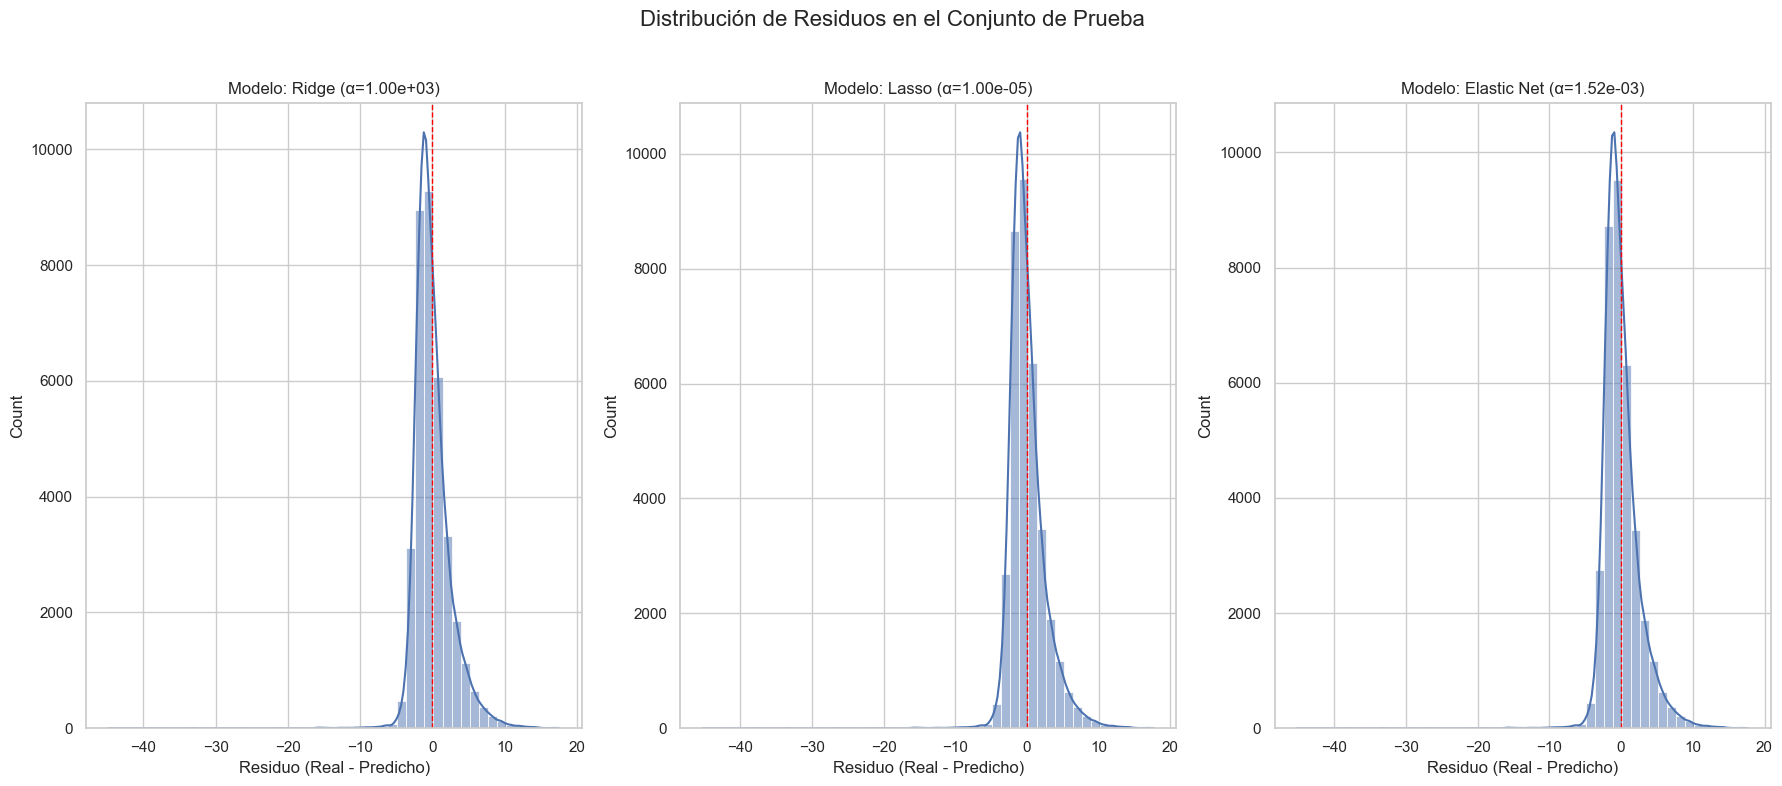

In [ ]:
def analizar_residuos_optimos(X_train, y_train, X_test, y_test, df_results):
    """
    Identifica el mejor Alpha (basado en R2 en 'test') para cada modelo, 
    re-entrena los modelos, calcula los residuos en el conjunto de prueba y los grafica.
    """
    # 1. Encontrar el Alpha óptimo para cada modelo
    df_test = df_results[df_results['Conjunto'] == 'test'].copy()
    idx_optimos = df_test.groupby('Modelo')['R2'].idxmax()
    alphas_optimos = df_test.loc[idx_optimos, ['Modelo', 'Alpha']].set_index('Modelo')['Alpha'].to_dict()

    residuos = {}
    
    # 2. Re-entrenar y calcular residuos
    for modelo_nombre, alpha_optimo in alphas_optimos.items():
        
        # Seleccionar el objeto de modelo correcto
        if modelo_nombre == 'Ridge':
            modelo = Ridge(alpha=alpha_optimo)
        elif modelo_nombre == 'Lasso':
            modelo = Lasso(alpha=alpha_optimo, max_iter=10000)
        elif modelo_nombre == 'Elastic Net':
            modelo = ElasticNet(alpha=alpha_optimo, l1_ratio=0.5, max_iter=10000)
        else:
            continue
            
        modelo.fit(X_train, y_train)
        
        # Calcular predicciones en el conjunto de prueba
        y_pred = modelo.predict(X_test)
        
        # Calcular los residuos (y_real - y_pred)
        residuos[modelo_nombre] = np.array(y_test).ravel() - y_pred.ravel()
        
    # Graficar
    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    fig.suptitle('Distribución de Residuos en el Conjunto de Prueba', fontsize=16)

    modelos = ['Ridge', 'Lasso', 'Elastic Net']
    
    for i, modelo in enumerate(modelos):
        if modelo in residuos:
            sns.histplot(residuos[modelo], kde=True, ax=axes[i], bins=50)
            axes[i].set_title(f'Modelo: {modelo} (α={alphas_optimos[modelo]:.2e})')
            axes[i].set_xlabel('Residuo (Real - Predicho)')
            # Dibujar la línea en cero para verificar el sesgo
            axes[i].axvline(0, color='red', linestyle='--', linewidth=1) 
            
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    
analizar_residuos_optimos(X_train, y_train, X_test, y_test, df_results)

La tendencia general de los residuos es concentrarse alrededor de cero con una forma de campana. Sugiere que los errores del modelo se distribuyen de manera aproximadamente normal. El pico de la campana se alinea perfectamente con la línea roja central (cero). Esto confirma que el modelo no tiene sesgo sistémico; los errores aleatorios de subestimación y sobreestimación se equilibran.

Sin embargo, aunque la parte central es normal, los gráficos muestran colas largas y pesadas, que se extienden hasta 200. Esto quiere decir que el modelo falla sustancialmente en predecir un pequeño porcentaje de los viajes. Es probable que la alta varianza de la variable objetivo (la tarifa) esté provocando estos errores extremos, y al modelo le faltan características clave para explicar estos viajes atípicos.

Hiperparametros

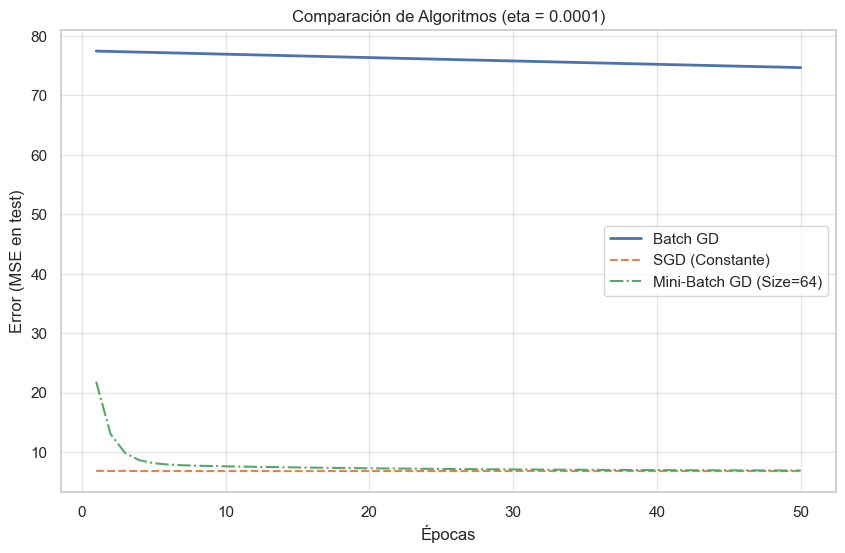

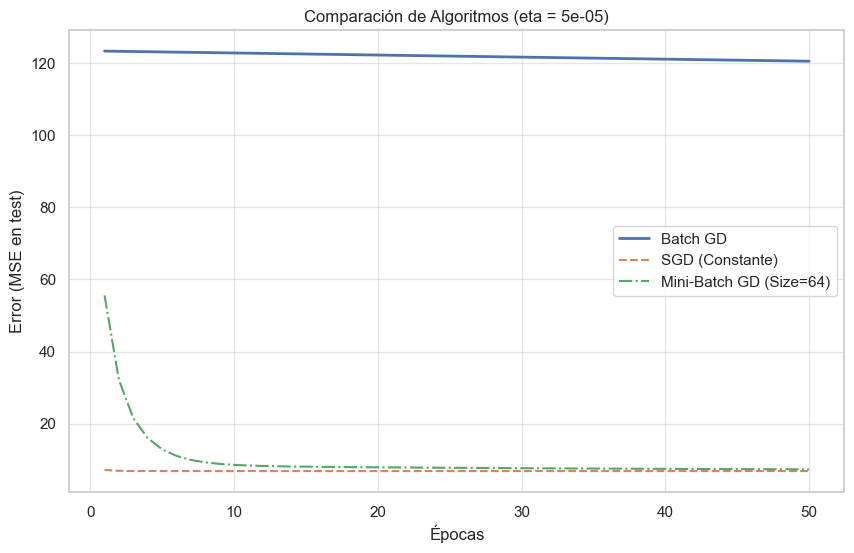

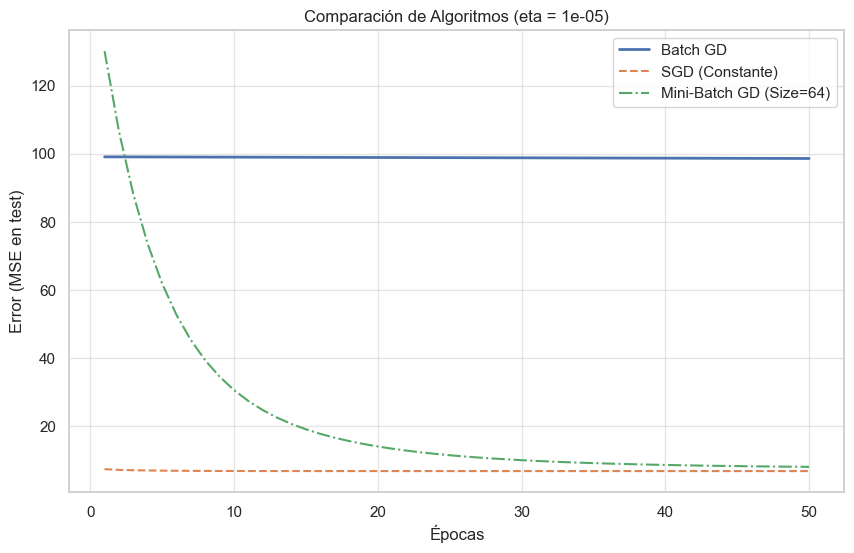

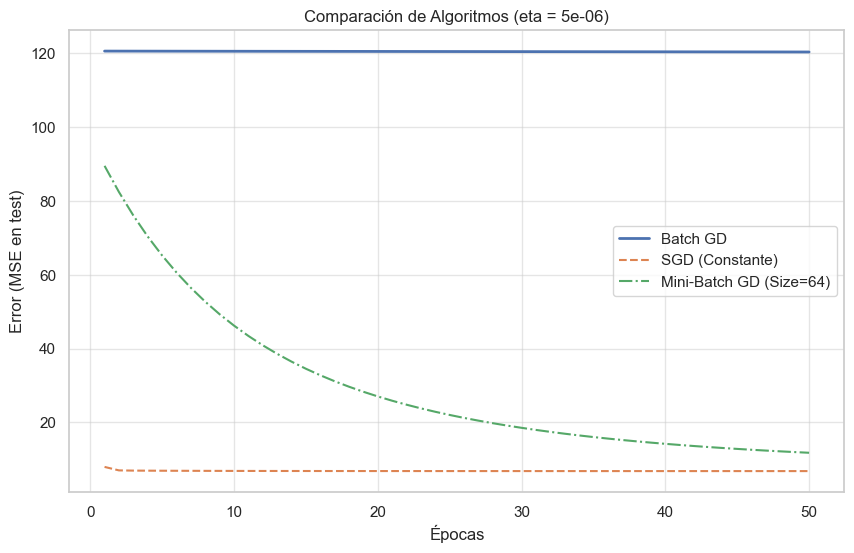

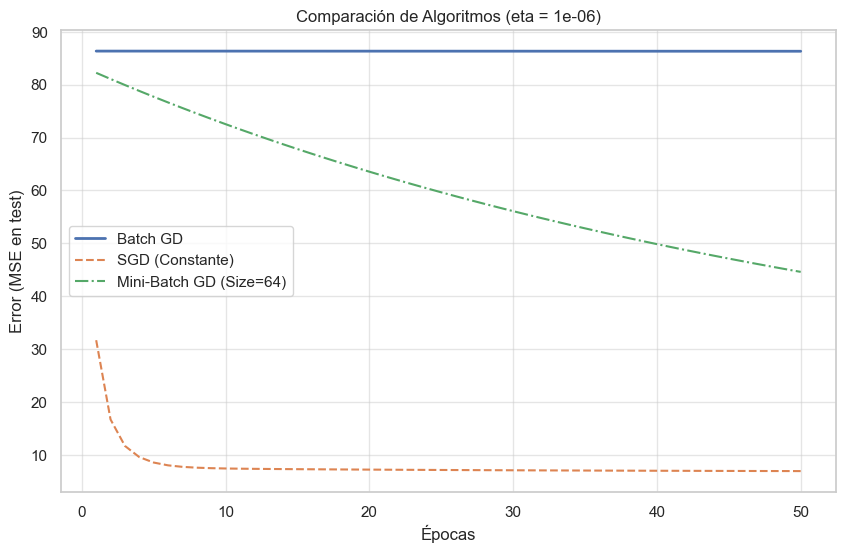

In [86]:
X_train_np = np.asarray(X_train); X_test_np = np.asarray(X_test)
y_train_np = np.asarray(y_train).reshape(-1, 1); y_test_np = np.asarray(y_test).reshape(-1, 1)
X_train_bias = np.c_[np.ones((len(X_train_np), 1)), X_train_np]
X_test_bias = np.c_[np.ones((len(X_test_np), 1)), X_test_np]

m = len(X_train_np) 
n_features = X_train_np.shape[1]


n_epochs = 50
batch_size = 64
# Reducimos las tasas iniciales para evitar divergencia y NaN.
etas = [0.0001, 0.00005, 0.00001, 0.000005, 0.000001]

for eta in etas:
    
    # Inicialización de pesos (limpia para cada experimento)
    theta_batch = np.random.randn(n_features + 1, 1)
    theta_sgd = np.random.randn(n_features + 1, 1)
    theta_mbgd = np.random.randn(n_features + 1, 1)

    errors = {"batch": [], "sgd": [], "minibatch": []}
    
    for epoch in range(n_epochs):
        # Barajar los datos en cada época
        permutation = np.random.permutation(m)
        X_shuffled = X_train_bias[permutation]
        y_shuffled = y_train_np[permutation]

        # BGD
        grad_batch = 2 / m * X_train_bias.T.dot(X_train_bias.dot(theta_batch) - y_train_np)
        theta_batch -= eta * grad_batch
        
        
        # Mini-Batch
        for i in range(0, m, batch_size):
            xi_mbgd = X_shuffled[i:i + batch_size]
            yi_mbgd = y_shuffled[i:i + batch_size]
            
            # Gradiente y Actualización (con ETA CONSTANTE)
            grad_mbgd = 2 / len(xi_mbgd) * xi_mbgd.T.dot(xi_mbgd.dot(theta_mbgd) - yi_mbgd)
            theta_mbgd -= eta * grad_mbgd

        # SGD
        for i in range(m):
            # Obtener una sola muestra
            xi_sgd = X_shuffled[i:i + 1]
            yi_sgd = y_shuffled[i:i + 1]
            
            # Gradiente y Actualización (con ETA CONSTANTE)
            grad_sgd = 2 * xi_sgd.T.dot(xi_sgd.dot(theta_sgd) - yi_sgd)
            theta_sgd -= eta * grad_sgd
            

        # Calcular errores en test
        y_pred_batch = X_test_bias.dot(theta_batch)
        y_pred_sgd = X_test_bias.dot(theta_sgd)
        y_pred_mbgd = X_test_bias.dot(theta_mbgd)

        errors["batch"].append(mean_squared_error(y_test_np, y_pred_batch))
        errors["sgd"].append(mean_squared_error(y_test_np, y_pred_sgd))
        errors["minibatch"].append(mean_squared_error(y_test_np, y_pred_mbgd))

    # Graficar por cada eta 
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, n_epochs + 1), errors["batch"], label="Batch GD", linewidth=2)
    plt.plot(range(1, n_epochs + 1), errors["sgd"], label="SGD (Constante)", linestyle='--')
    plt.plot(range(1, n_epochs + 1), errors["minibatch"], label=f"Mini-Batch GD (Size={batch_size})", linestyle='-.')
    
    plt.xlabel("Épocas")
    plt.ylabel("Error (MSE en test)")
    plt.title(f"Comparación de Algoritmos (eta = {eta})")
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.show()

SGD y Mini-Batch GD:

Rango Óptimo de Convergencia (eta menor o igual a 5e - 05): SGD y Mini-Batch GD son los optimizadores más efectivos. Con tasas como 0.0001 o 5e - 05, ambos convergen al MSE mínimo de aproximadamente 7.5 - 5 en menos de 10 épocas. 

Velocidad de SGD: El SGD (Constante) es el más eficiente en la mayoría de los casos, logrando el MSE mínimo en la Época 1 o 2 (sacando 1e - 06 donde tarda entre 8 y 10).Comportamiento de 

Mini-Batch GD: La curva de Mini-Batch GD se vuelve notablemente sensible a la eta. Mientras que con eta alta converge rápidamente, con eta muy baja la convergencia se hace lenta y gradual, requiriendo más de 40 épocas para acercarse al mínimo.

Batch GD:

Comportamiento anómalo: El BGD muestra una convergencia deficiente o nula en todos los rangos probados. Estancamiento Persistente: En casi todos los casos (eta menor o igual a 0.0001) el BGD se estanca inmediatamente en un MSE muy alto (entre 85 y 125) y su curva es casi horizontal. Razón: El gradiente promedio de todo el dataset es tan pequeño que la actualización de los pesos es insignificante.

In [87]:
# Alphas distintas para probar
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

results = []

#  Ridge
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results.append({
        "Modelo": "Ridge",
        "Alpha": alpha,
        "Conjunto": "train",
        "R2": r2_score(y_train, y_train_pred),
        "MSE": mean_squared_error(y_train, y_train_pred)
    })
    results.append({
        "Modelo": "Ridge",
        "Alpha": alpha,
        "Conjunto": "test",
        "R2": r2_score(y_test, y_test_pred),
        "MSE": mean_squared_error(y_test, y_test_pred)
    })


# Lasso
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results.append({
        "Modelo": "Lasso",
        "Alpha": alpha,
        "Conjunto": "train",
        "R2": r2_score(y_train, y_train_pred),
        "MSE": mean_squared_error(y_train, y_train_pred)
    })
    results.append({
        "Modelo": "Lasso",
        "Alpha": alpha,
        "Conjunto": "test",
        "R2": r2_score(y_test, y_test_pred),
        "MSE": mean_squared_error(y_test, y_test_pred)
    })

df_results_opt = pd.DataFrame(results)

In [88]:
metricas_conj(df_results_opt, 'train')

C:\Windows\Temp\ipykernel_19744\1970636183.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mejores_3 = metricas.groupby('Modelo', group_keys=False).apply(


,Modelo,Alpha,Conjunto,R2,MSE
12,Lasso,0.001,train,0.628140,6.683720
14,Lasso,0.010,train,0.627941,6.687295
16,Lasso,0.100,train,0.625075,6.738807
0,Ridge,0.001,train,0.628147,6.683599
2,Ridge,0.010,train,0.628147,6.683599
4,Ridge,0.100,train,0.628147,6.683599


In [89]:
metricas_conj(df_results_opt, 'test')

C:\Windows\Temp\ipykernel_19744\1970636183.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mejores_3 = metricas.groupby('Modelo', group_keys=False).apply(


,Modelo,Alpha,Conjunto,R2,MSE
13,Lasso,0.001,test,0.616099,6.794369
15,Lasso,0.010,test,0.615943,6.797124
17,Lasso,0.100,test,0.613564,6.839223
11,Ridge,100.000,test,0.616116,6.794056
9,Ridge,10.000,test,0.616106,6.794240
7,Ridge,1.000,test,0.616105,6.794260


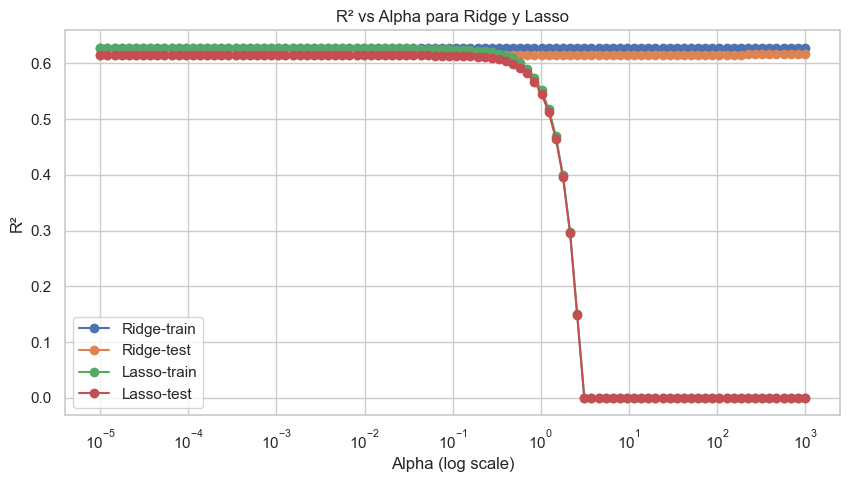

In [90]:
plt.figure(figsize=(10,5))
for model_name in ['Ridge','Lasso']:
    for conjunto in ['train','test']:
        subset = df_results[(df_results['Modelo']==model_name) & (df_results['Conjunto']==conjunto)]
        plt.plot(subset['Alpha'], subset['R2'], marker='o', label=f"{model_name}-{conjunto}")

plt.xscale('log')
plt.xlabel("Alpha (log scale)")
plt.ylabel("R²")
plt.title("R² vs Alpha para Ridge y Lasso")
plt.legend()
plt.grid(True)
plt.show()

Hay una diferencia de 0.0120414576 entre train y test de Lasso. Por el lado de Ridge, 0.0120304602. No se obtiene ninguna mejora significativa con la regularización.

Teniendo en cuenta el segundo gráfico:

Rango de alpha bajo (baja regularización): Para valores de alpha entre 10 elevado a la -4 y 10 elevado a la 0
(es decir, alpha menor o igual a 1 ), las cuatro curvas (Ridge-train/test y Lasso-train/test) se mantienen planas y estables. En este amplio rango, los modelos se comportan esencialmente como una Regresión Lineal sin penalización. Indica que no había overfitting significativo que corregir.

Rango de alpha alto (fuerte regularización): Cuando 
 se vuelve mucho mayor que 1, las curvas caen en picada. Esto quiere decir que una penalización excesiva hace que el modelo ignore las características, llevando a un underfitting.

In [91]:
# Modelos y sus hiperparámetros
modelos = [
    ("LinearRegression", LinearRegression(), None),
    ("Ridge", Ridge(alpha=1.0), 1.0),
    ("Lasso", Lasso(alpha=0.1, max_iter=10000), 0.1),
    ("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000), 0.1)
]

resultados = []

for name, model, alpha in modelos:
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    resultados.append({
        "Modelo": name,
        "Alpha": alpha,
        "R2_train": r2_score(y_train, y_train_pred),
        "R2_test": r2_score(y_test, y_test_pred),
        "MSE_train": mean_squared_error(y_train, y_train_pred),
        "MSE_test": mean_squared_error(y_test, y_test_pred)
    })

# Resultados
comparacion = pd.DataFrame(resultados)
comparacion

,Modelo,Alpha,R2_train,R2_test,MSE_train,MSE_test
0,LinearRegression,NaN,0.628147,0.616105,6.683599,6.794263
1,Ridge,1.0,0.628147,0.616105,6.683599,6.794260
2,Lasso,0.1,0.625075,0.613564,6.738807,6.839223
3,ElasticNet,0.1,0.622440,0.611635,6.786167,6.873368
